# 🐄 Projeto de Visão Computacional — Fase 6 | FIAP  
### FarmTech Solutions — Detecção de Bovinos e Funcionários

## 📌 Apresentação do Projeto

Este projeto foi desenvolvido como parte da **Fase 6**.
O objetivo é aplicar técnicas de **Visão Computacional** para solucionar um cenário real:  
a **detecção de bovinos e funcionários** em imagens capturadas em ambientes rurais.

A solução busca demonstrar na prática a capacidade dos modelos de Deep Learning em reconhecer objetos distintos, comparar diferentes abordagens de rede neural e analisar criticamente desempenho, custo computacional e aplicabilidade prática.

---

## 🧭 Cenário Proposto

- Detectar **bovinos (classe A)** e **funcionários (classe B)** em imagens.  
- Comparar diferentes modelos de rede neural para a mesma tarefa.  
- Avaliar os resultados em termos de **precisão, recall, mAP e tempo de inferência**.  

---

## 🧪 Modelos Avaliados

1. **YOLO Adaptável (Fine-tuning) - 30 e 60 épocas** — Treinado com dataset próprio.  
2. **YOLO Padrão (COCO)** — Modelo pré-treinado, sem customização.  
3. **CNN do Zero** — Arquitetura simples de classificação.

---

## 📊 Objetivos Técnicos

- Construir e rotular dataset com pelo menos 80 imagens (40 por classe).  
- Realizar treinamento, validação e teste no YOLO.  
- Comparar o desempenho de YOLO e CNN.  
- Avaliar criticamente:
  - Facilidade de uso
  - Precisão e recall
  - Tempo de treinamento
  - Tempo de inferência
- Produzir conclusões e recomendações práticas.

---



## ENTREGA 1: YOLO Adaptável (Fine-tuning) - 30 e 60 épocas — Treinado com dataset próprio.

In [3]:
# 0) Preparação e conexão com o Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado!')

import os

BASE = '/content/drive/MyDrive/fase6_yolo'
for p in [
    f'{BASE}/images/train', f'{BASE}/images/val', f'{BASE}/images/test',
    f'{BASE}/labels/train', f'{BASE}/labels/val', f'{BASE}/labels/test'
]:
    os.makedirs(p, exist_ok=True)

print('Estrutura criada em', BASE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado!
Estrutura criada em /content/drive/MyDrive/fase6_yolo


In [4]:
# 1) Instalação e checagem do ambiente
!nvidia-smi || echo 'GPU não disponível'
%pip install -q ultralytics
from ultralytics import YOLO
print('Ultralytics OK!')


Tue Oct 14 19:48:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# 2) Checagem de integridade: imagens x labels
import os, glob, pathlib, collections

BASE = '/content/drive/MyDrive/fase6_yolo'
for split in ['train','val','test']:
    imgs  = {pathlib.Path(p).stem for p in glob.glob(f'{BASE}/images/{split}/*')}
    lbls  = {pathlib.Path(p).stem for p in glob.glob(f'{BASE}/labels/{split}/*.txt')}
    only_img = imgs - lbls
    only_lbl = lbls - imgs
    print(f'[{split}] imgs:{len(imgs)} | labels:{len(lbls)} | sem label:{len(only_img)} | sem img:{len(only_lbl)}')
    if only_img: print('  -> sem label:', list(sorted(only_img))[:5])
    if only_lbl: print('  -> sem img  :', list(sorted(only_lbl))[:5])


[train] imgs:64 | labels:64 | sem label:0 | sem img:0
[val] imgs:8 | labels:8 | sem label:0 | sem img:0
[test] imgs:8 | labels:8 | sem label:0 | sem img:0


In [6]:
import yaml, os

BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML_PATH = f'{BASE}/data.yaml'

data_yaml = {
    'path': BASE,
    'train': f'{BASE}/images/train',
    'val':   f'{BASE}/images/val',
    'test':  f'{BASE}/images/test',
    'nc': 2,
    'names': ['bovino','funcionario']  # 0=bovino, 1=funcionario
}

os.makedirs(BASE, exist_ok=True)
with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print('data.yaml gravado em:', DATA_YAML_PATH)
print(open(DATA_YAML_PATH).read())

# garantia:
import os
assert os.path.exists(DATA_YAML_PATH), 'data.yaml não foi criado!'


data.yaml gravado em: /content/drive/MyDrive/fase6_yolo/data.yaml
path: /content/drive/MyDrive/fase6_yolo
train: /content/drive/MyDrive/fase6_yolo/images/train
val: /content/drive/MyDrive/fase6_yolo/images/val
test: /content/drive/MyDrive/fase6_yolo/images/test
nc: 2
names:
- bovino
- funcionario



## 🧠 Modelo: YOLOv8n (Ultralytics)

### 📂 Dataset
- Imagens rotuladas no **MakeSense.ai** em formato YOLO.  
- Divisão em **train**, **val** e **test** com diretórios `images/` e `labels/`.  
- Total de **80 imagens**, distribuídas em:
  - 64 para treinamento
  - 8 para validação
  - 8 para teste

### 🏷️ Classes
- Classe 0: **bovino**  
- Classe 1: **funcionário**

### ⚙️ Hiperparâmetros principais
- `imgsz = 640`  
- `batch = 16`  
- `epochs = {30, 60}`

### 📊 Avaliação
- Métricas utilizadas:
  - Precision
  - Recall
  - mAP50
  - mAP50-95
  - Inspeção visual das predições (`*_pred.jpg`)

### 🧪 Treinamentos realizados
- **Ep30:** 30 épocas com `yolov8n.pt`  
- **Ep60:** 60 épocas com `yolov8n.pt`  
- Arquivo de configuração: `data.yaml`  
- Pesos finais salvos em:
  - `/content/runs/train/fase6_ep30/weights/best.pt`  
  - `/content/runs/train/fase6_ep60/weights/best.pt`


In [8]:
# 4) Treinar YOLO (30 e 60 épocas)
!nvidia-smi || echo '⚠️  GPU não disponível'
%pip install -q ultralytics
from ultralytics import YOLO

BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML_PATH = f'{BASE}/data.yaml'

# modelo base (pode usar 'yolov8s.pt' para melhor precisão se couber na GPU)
model30 = YOLO('yolov8n.pt')
results_30 = model30.train(
    data=DATA_YAML_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    project='runs/train',
    name='fase6_ep30',
    exist_ok=True
)

model60 = YOLO('yolov8n.pt')
results_60 = model60.train(
    data=DATA_YAML_PATH,
    epochs=60,
    imgsz=640,
    batch=16,
    project='runs/train',
    name='fase6_ep60',
    exist_ok=True
)

print('✅ Treinos concluídos.')
print('📁 Pesos 30 ep:', '/content/runs/train/fase6_ep30/weights/best.pt')
print('📁 Pesos 60 ep:', '/content/runs/train/fase6_ep60/weights/best.pt')



Tue Oct 14 19:49:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## ✅ Validação e Teste

Rodamos a etapa de **validação** (`val`) e **teste** (`test`) para ambos os modelos treinados — **ep30** e **ep60** — com o objetivo de avaliar o desempenho de cada um de forma consistente.

### 📊 Métricas Avaliadas
- **Precision**
- **Recall**
- **mAP50**
- **mAP50-95**

### 🖼️ Saídas Geradas
- Imagens de predição:
  - `val_batch0_pred.jpg`
  - `test_batch0_pred.jpg`
- Matrizes de confusão e curvas Precision-Recall:
  - Localizadas na pasta de `runs` gerada pelo YOLO.

### 🧪 Objetivo
Essa etapa permite verificar:
- A capacidade de generalização dos modelos;
- O impacto da quantidade de épocas no desempenho;
- A robustez das detecções em imagens nunca vistas.



In [9]:
# =========================
# 5) Avaliações VAL + TEST para ep30 e ep60
# =========================
from ultralytics import YOLO
import os, glob

BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML_PATH = f'{BASE}/data.yaml'

BEST30 = '/content/runs/train/fase6_ep30/weights/best.pt'
BEST60 = '/content/runs/train/fase6_ep60/weights/best.pt'

# 1) Conferir se os pesos existem
assert os.path.exists(BEST30), f'Peso não encontrado: {BEST30}'
assert os.path.exists(BEST60), f'Peso não encontrado: {BEST60}'
assert os.path.exists(DATA_YAML_PATH), f'data.yaml não encontrado: {DATA_YAML_PATH}'

# 2) (Opcional) Limpar caches de val e test para forçar re-leitura
for p in glob.glob(f'{BASE}/**/*.cache', recursive=True):
    try:
        os.remove(p)
        print('🧹 Removido cache:', p)
    except Exception as e:
        print('Falhou ao remover', p, e)

# 3) Avaliação em VAL (para comparação direta com o que o YOLO mostrou no fim do treino)
print('\n=== VALIDAÇÃO (split=val) :: ep30 ===')
YOLO(BEST30).val(
    data=DATA_YAML_PATH,
    imgsz=640,
    split='val',
    project='runs/val',
    name='ep30_reval',
    exist_ok=True,
    conf=0.10,        # desenha caixas mesmo com conf mais baixa (opcional)
)

print('\n=== VALIDAÇÃO (split=val) :: ep60 ===')
YOLO(BEST60).val(
    data=DATA_YAML_PATH,
    imgsz=640,
    split='val',
    project='runs/val',
    name='ep60_reval',
    exist_ok=True,
    conf=0.10,
)

print('\n🗂 Abra:')
print('/content/runs/val/ep30_reval/val_batch0_labels.jpg')
print('/content/runs/val/ep30_reval/val_batch0_pred.jpg')
print('/content/runs/val/ep60_reval/val_batch0_labels.jpg')
print('/content/runs/val/ep60_reval/val_batch0_pred.jpg')

# 4) Avaliação em TEST (dados nunca vistos)
print('\n=== TESTE (split=test) :: ep30 ===')
YOLO(BEST30).val(
    data=DATA_YAML_PATH,
    imgsz=640,
    split='test',         # 👈 ESSENCIAL p/ usar images/test
    project='runs/test',
    name='ep30_test',
    exist_ok=True,
    conf=0.10,
)

print('\n=== TESTE (split=test) :: ep60 ===')
YOLO(BEST60).val(
    data=DATA_YAML_PATH,
    imgsz=640,
    split='test',         # 👈 ESSENCIAL p/ usar images/test
    project='runs/test',
    name='ep60_test',
    exist_ok=True,
    conf=0.10,
)

print('\n🗂 Abra (TESTE):')
print('/content/runs/test/ep30_test/test_batch0_labels.jpg')
print('/content/runs/test/ep30_test/test_batch0_pred.jpg')
print('/content/runs/test/ep60_test/test_batch0_labels.jpg')
print('/content/runs/test/ep60_test/test_batch0_pred.jpg')


🧹 Removido cache: /content/drive/MyDrive/fase6_yolo/labels/train.cache
🧹 Removido cache: /content/drive/MyDrive/fase6_yolo/labels/val.cache

=== VALIDAÇÃO (split=val) :: ep30 ===
Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 185.4±203.3 MB/s, size: 745.0 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/val... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 173.4it/s 0.0s
val: New cache created: /content/drive/MyDrive/fase6_yolo/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.3it/s 3.4s
                   all          8         23      0.833      0.688      0.774      0.436
                bovino          6         16      0.666      0.375      0.554      0.278
           funcionario          6          7          1      

In [10]:
from ultralytics import YOLO

BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML_PATH = f'{BASE}/data.yaml'
BEST60 = '/content/runs/train/fase6_ep60/weights/best.pt'

# Avaliação no conjunto de TESTE
YOLO(BEST60).val(
    data=DATA_YAML_PATH,
    imgsz=640,
    split='test',              # 👈 ESSENCIAL
    project='runs/test',
    name='ep60_test',
    exist_ok=True
)

print('Resultados de teste gerados em:')
print('/content/runs/test/ep60_test/')


Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 212.5±161.4 MB/s, size: 673.6 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 14.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.6it/s 1.7s
                   all          8         28       0.15      0.738      0.473      0.213
                bovino          6         21      0.203      0.619      0.337      0.133
           funcionario          6          7     0.0978      0.857       0.61      0.293
Speed: 0.3ms preprocess, 6.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/test/ep60_test
Resultados de teste gerados em:
/content/runs/test/ep60_test/


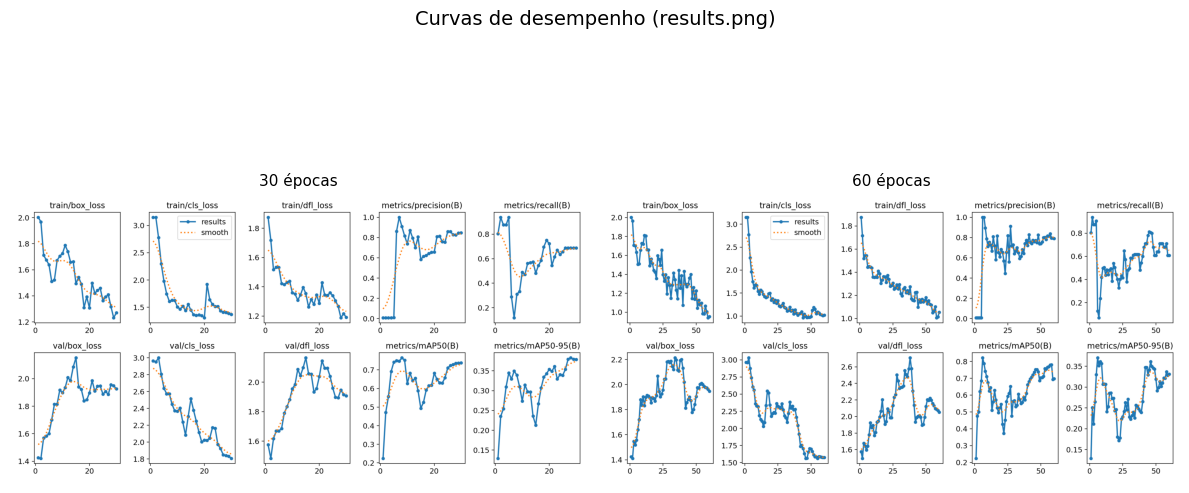

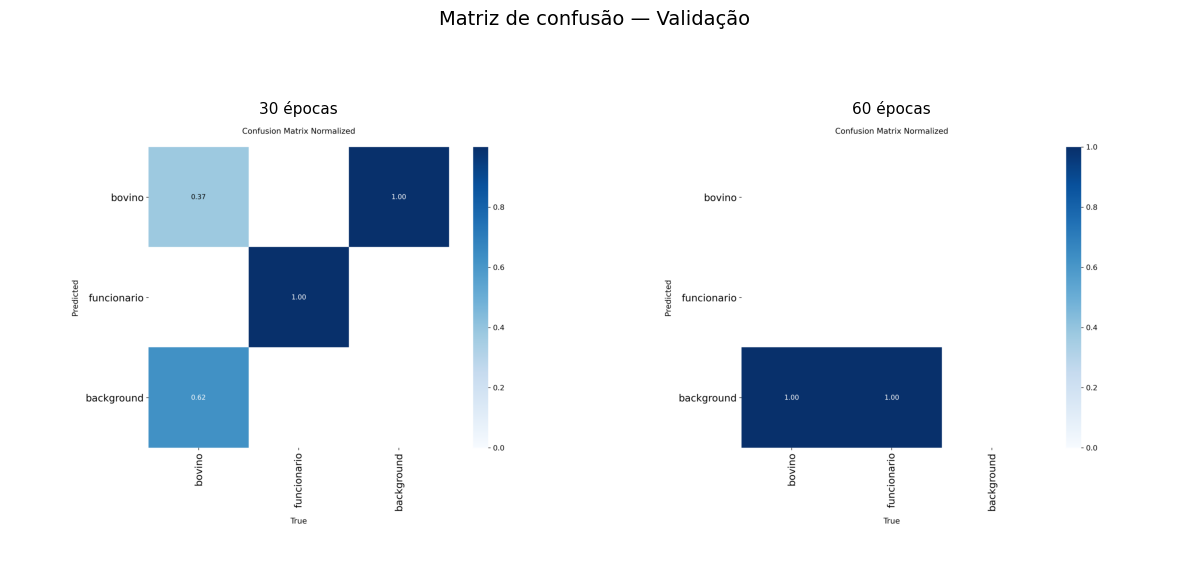

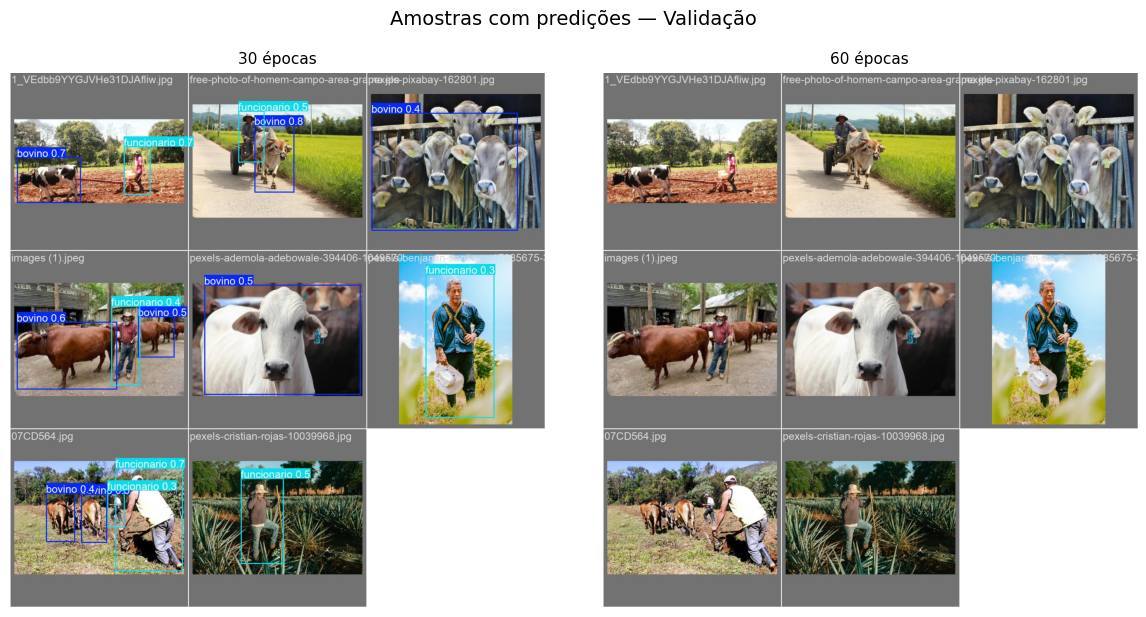

[Amostras com predições — Teste] nada para mostrar.
[Métricas — Validação (última época do run de validação)] sem results.csv encontrado.
[Métricas — Teste (última avaliação)] sem results.csv encontrado.


In [11]:
# ============================================
# Painel de resultados YOLO (30e/60e) — Treino, Val e Test
# ============================================
import os, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ---- caminhos dos seus runs (ajuste se mudou os names) ----
RUNS_TRAIN = {
    "30 épocas": "/content/runs/train/fase6_ep30",
    "60 épocas": "/content/runs/train/fase6_ep60",
}
RUNS_VAL = {
    "30 épocas": "/content/runs/val/ep30_reval",
    "60 épocas": "/content/runs/val/ep60_reval",
}
RUNS_TEST = {
    "30 épocas": "/content/runs/test/ep30_test",
    "60 épocas": "/content/runs/test/ep60_test",
}

# ---- utilitário: pega o primeiro arquivo existente na lista ----
def first_existing(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

# ---- utilitário: mostra um grid de imagens lado a lado ----
def show_side_by_side(title, images_dict, max_w=900):
    items = []
    for k, p in images_dict.items():
        if p and os.path.exists(p):
            items.append((k, p))
    if not items:
        print(f"[{title}] nada para mostrar.")
        return
    n = len(items)
    plt.figure(figsize=(min(20, 6*n), 6))
    plt.suptitle(title, fontsize=14, y=1.02)
    for i, (lbl, path) in enumerate(items, 1):
        img = Image.open(path)
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(lbl, fontsize=11)
    plt.tight_layout()
    plt.show()

# ---- utilitário: lê results.csv e devolve a última linha com métricas-chave ----
def read_metrics(run_dir):
    csv_path = os.path.join(run_dir, "results.csv")
    if not os.path.exists(csv_path):
        return None
    df = pd.read_csv(csv_path)
    if df.empty:
        return None
    last = df.iloc[-1]
    cols = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
    ]
    # alguns results.csv saem com nomes ligeiramente diferentes. Faz fallback simples:
    rename = {c:c for c in cols}
    for c in cols:
        if c not in last.index:
            # tenta variações comuns
            alt = c.replace("(B)", "").replace("metrics/", "")
            for candidate in [alt, f"{alt}(B)", c.replace("(B)","")]:
                if candidate in last.index:
                    rename[c] = candidate
                    break
    row = {k: float(last.get(rename[k], float("nan"))) for k in cols}
    return row

# ===================== 1) Curvas de treino (results.png) =====================
imgs_curvas = {}
for lbl, rdir in RUNS_TRAIN.items():
    path = first_existing([os.path.join(rdir, "results.png")])
    imgs_curvas[lbl] = path
show_side_by_side("Curvas de desempenho (results.png)", imgs_curvas)

# ===================== 2) Matrizes de confusão (VAL) =====================
imgs_cm_val = {}
for lbl, rdir in RUNS_VAL.items():
    path = first_existing([
        os.path.join(rdir, "confusion_matrix_normalized.png"),
        os.path.join(rdir, "confusion_matrix.png"),
    ])
    imgs_cm_val[lbl] = path
show_side_by_side("Matriz de confusão — Validação", imgs_cm_val)

# ===================== 3) Amostras com predições (VAL) =====================
imgs_val_preds = {}
for lbl, rdir in RUNS_VAL.items():
    path = first_existing([
        os.path.join(rdir, "val_batch0_pred.jpg"),
        os.path.join(rdir, "val_batch1_pred.jpg"),
    ])
    imgs_val_preds[lbl] = path
show_side_by_side("Amostras com predições — Validação", imgs_val_preds)

# ===================== 4) Amostras com predições (TEST) =====================
imgs_test_preds = {}
for lbl, rdir in RUNS_TEST.items():
    path = first_existing([
        os.path.join(rdir, "test_batch0_pred.jpg"),
        os.path.join(rdir, "test_batch1_pred.jpg"),
    ])
    imgs_test_preds[lbl] = path
show_side_by_side("Amostras com predições — Teste", imgs_test_preds)

# ===================== 5) Tabelas comparativas de métricas =====================
def metrics_table(runs_dict, title):
    rows = []
    for lbl, rdir in runs_dict.items():
        m = read_metrics(rdir)
        if m is None:
            continue
        row = {"Modelo": lbl, **m}
        rows.append(row)
    if not rows:
        print(f"[{title}] sem results.csv encontrado.")
        return
    df = pd.DataFrame(rows).set_index("Modelo")
    display(HTML(f"<h3>{title}</h3>"))
    display(df.style.format("{:.3f}"))

metrics_table(RUNS_VAL, "Métricas — Validação (última época do run de validação)")
metrics_table(RUNS_TEST, "Métricas — Teste (última avaliação)")


Pesos encontrados:
  30 épocas -> /content/runs/train/fase6_ep30/weights/best.pt
  60 épocas -> /content/runs/train/fase6_ep60/weights/best.pt

=== Avaliando em TEST: ep30_test ===
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 156.3±148.9 MB/s, size: 507.5 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 13.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.8it/s 1.3s
                   all          8         28      0.804      0.662      0.651      0.384
                bovino          6         21       0.83      0.466      0.484      0.255
           funcionario          6          7      0.778      0.857      0.818      0.514
Speed: 0.3ms preprocess, 6.0ms inferen

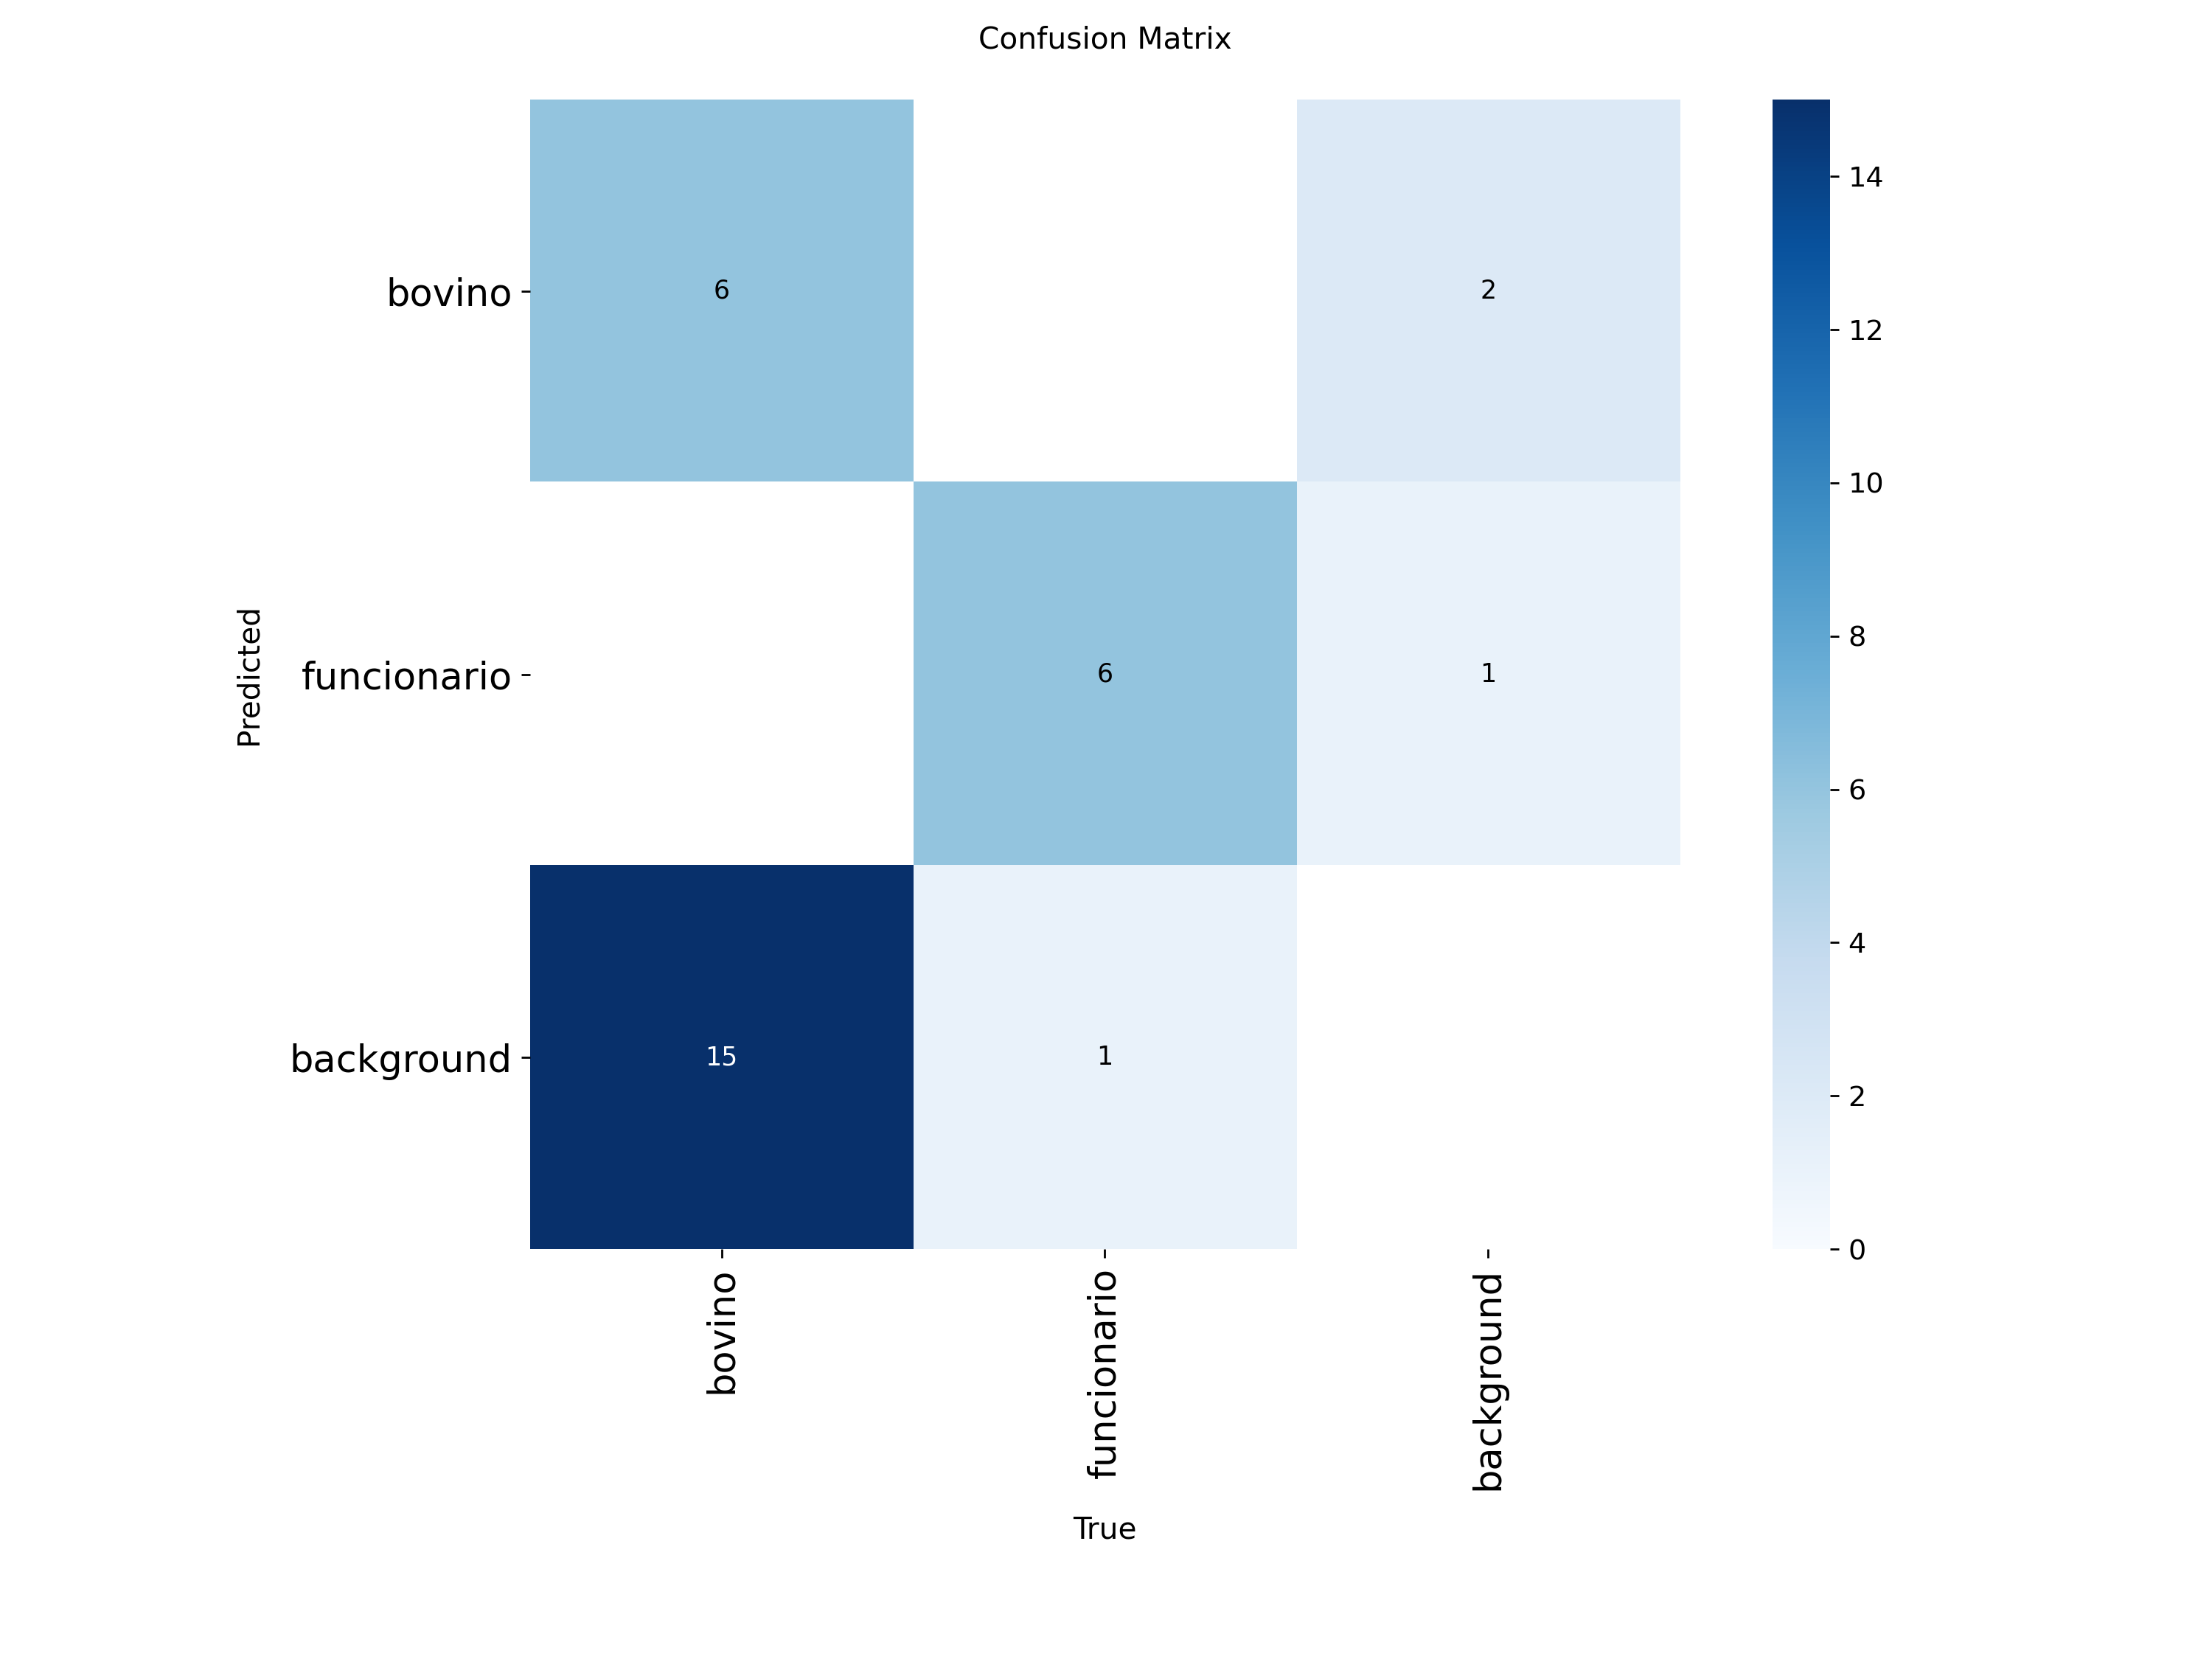


val_batch0_labels.jpg:


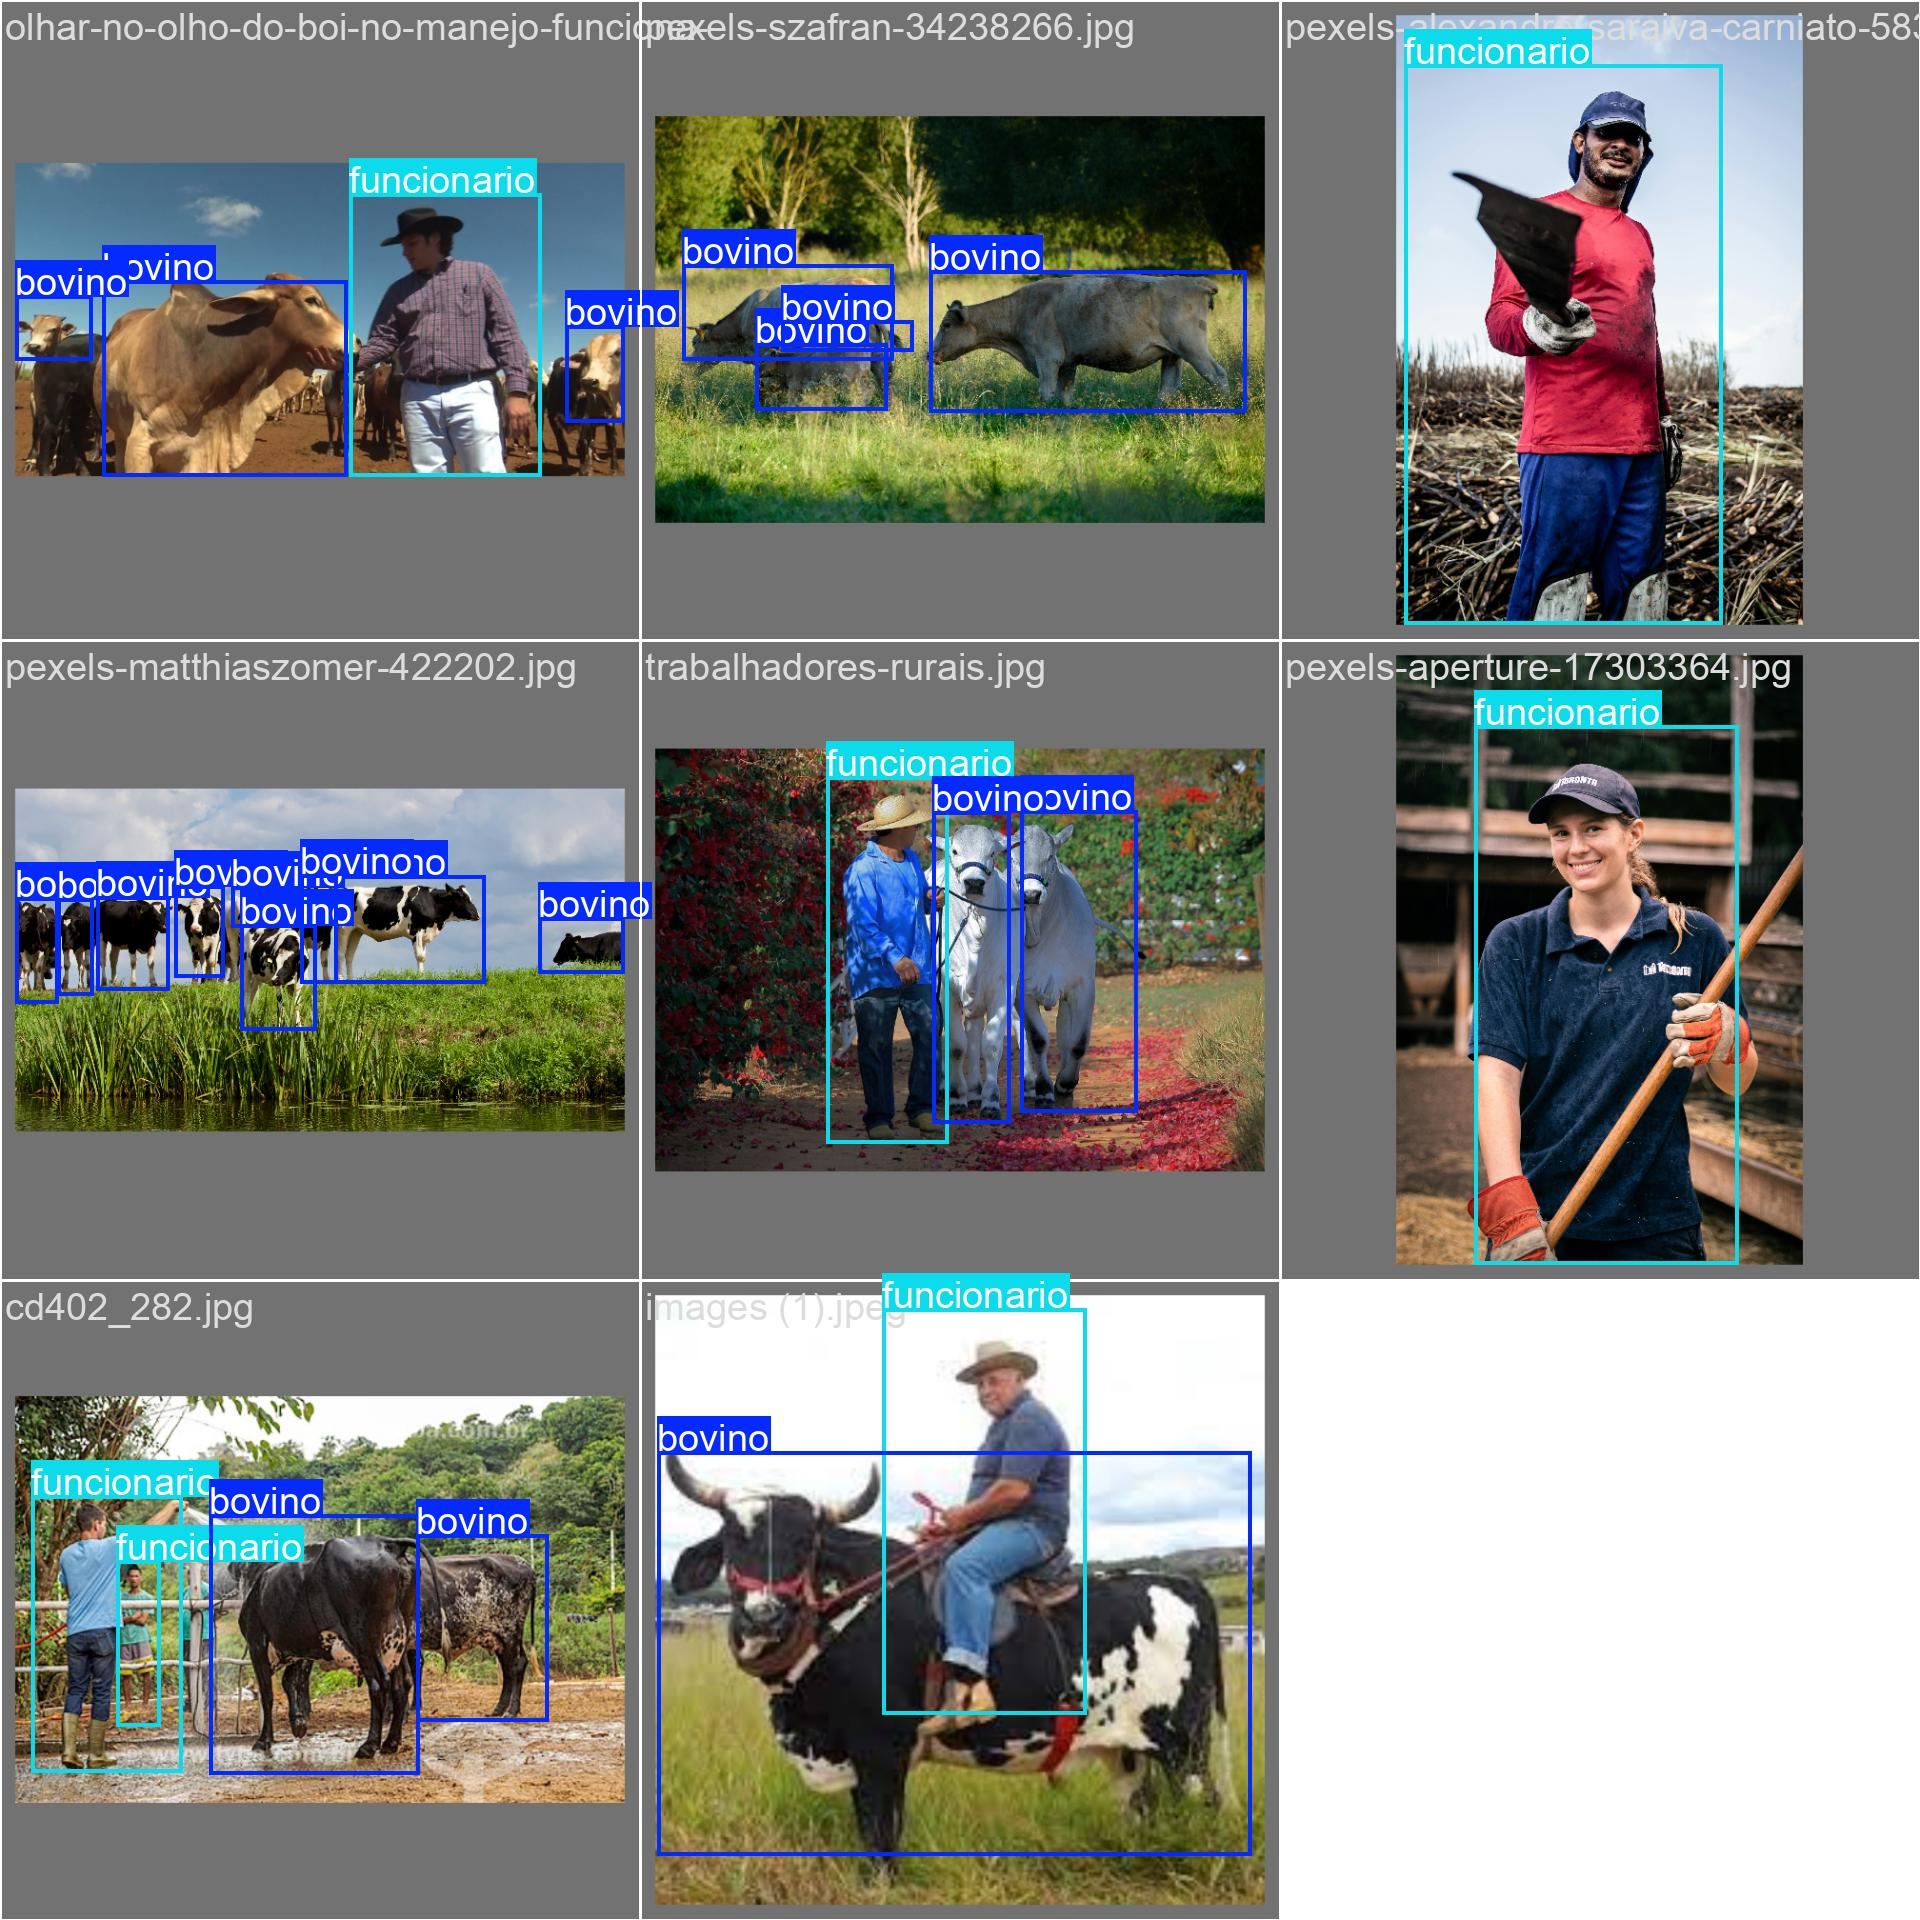


val_batch0_pred.jpg:


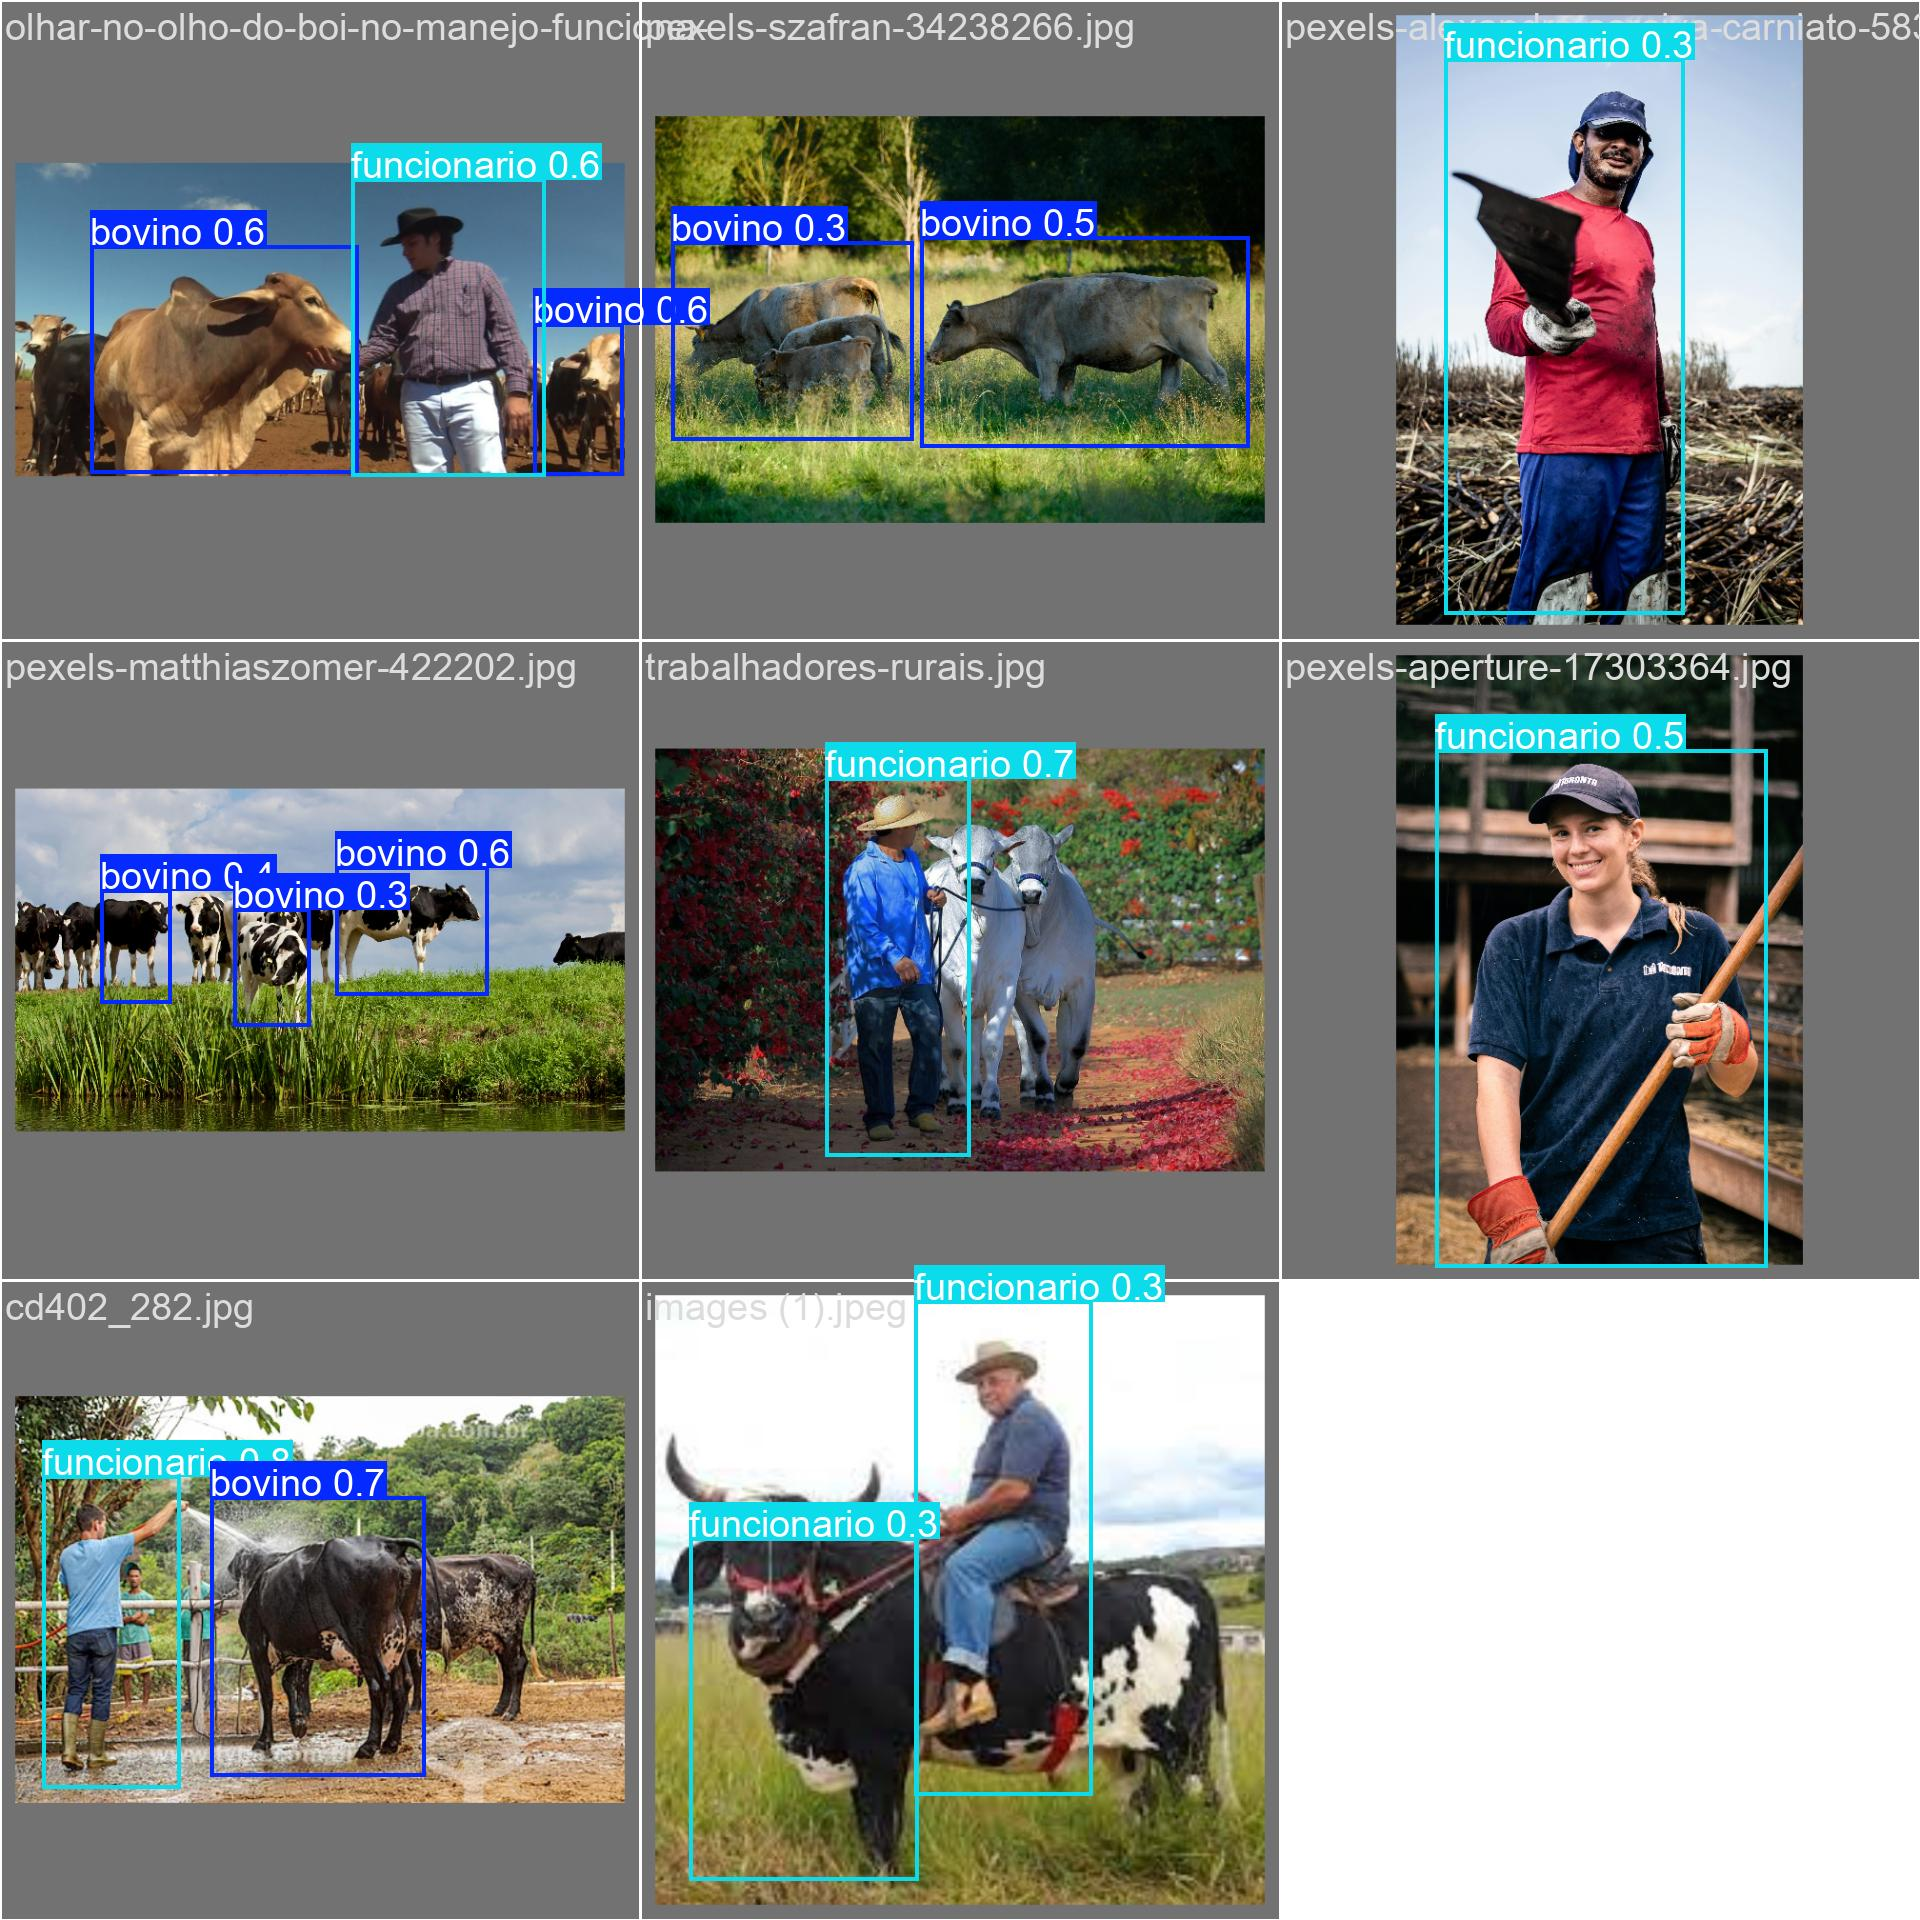


=== Avaliando em TEST: ep60_test ===
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 222.7±111.2 MB/s, size: 920.8 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 12.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.7it/s 1.4s
                   all          8         28       0.15      0.738      0.473      0.213
                bovino          6         21      0.203      0.619      0.337      0.133
           funcionario          6          7     0.0978      0.857       0.61      0.293
Speed: 1.0ms preprocess, 6.3ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /content/runs/test/ep60_test
Resultados salvos em: /content/runs/test/ep60_test

M

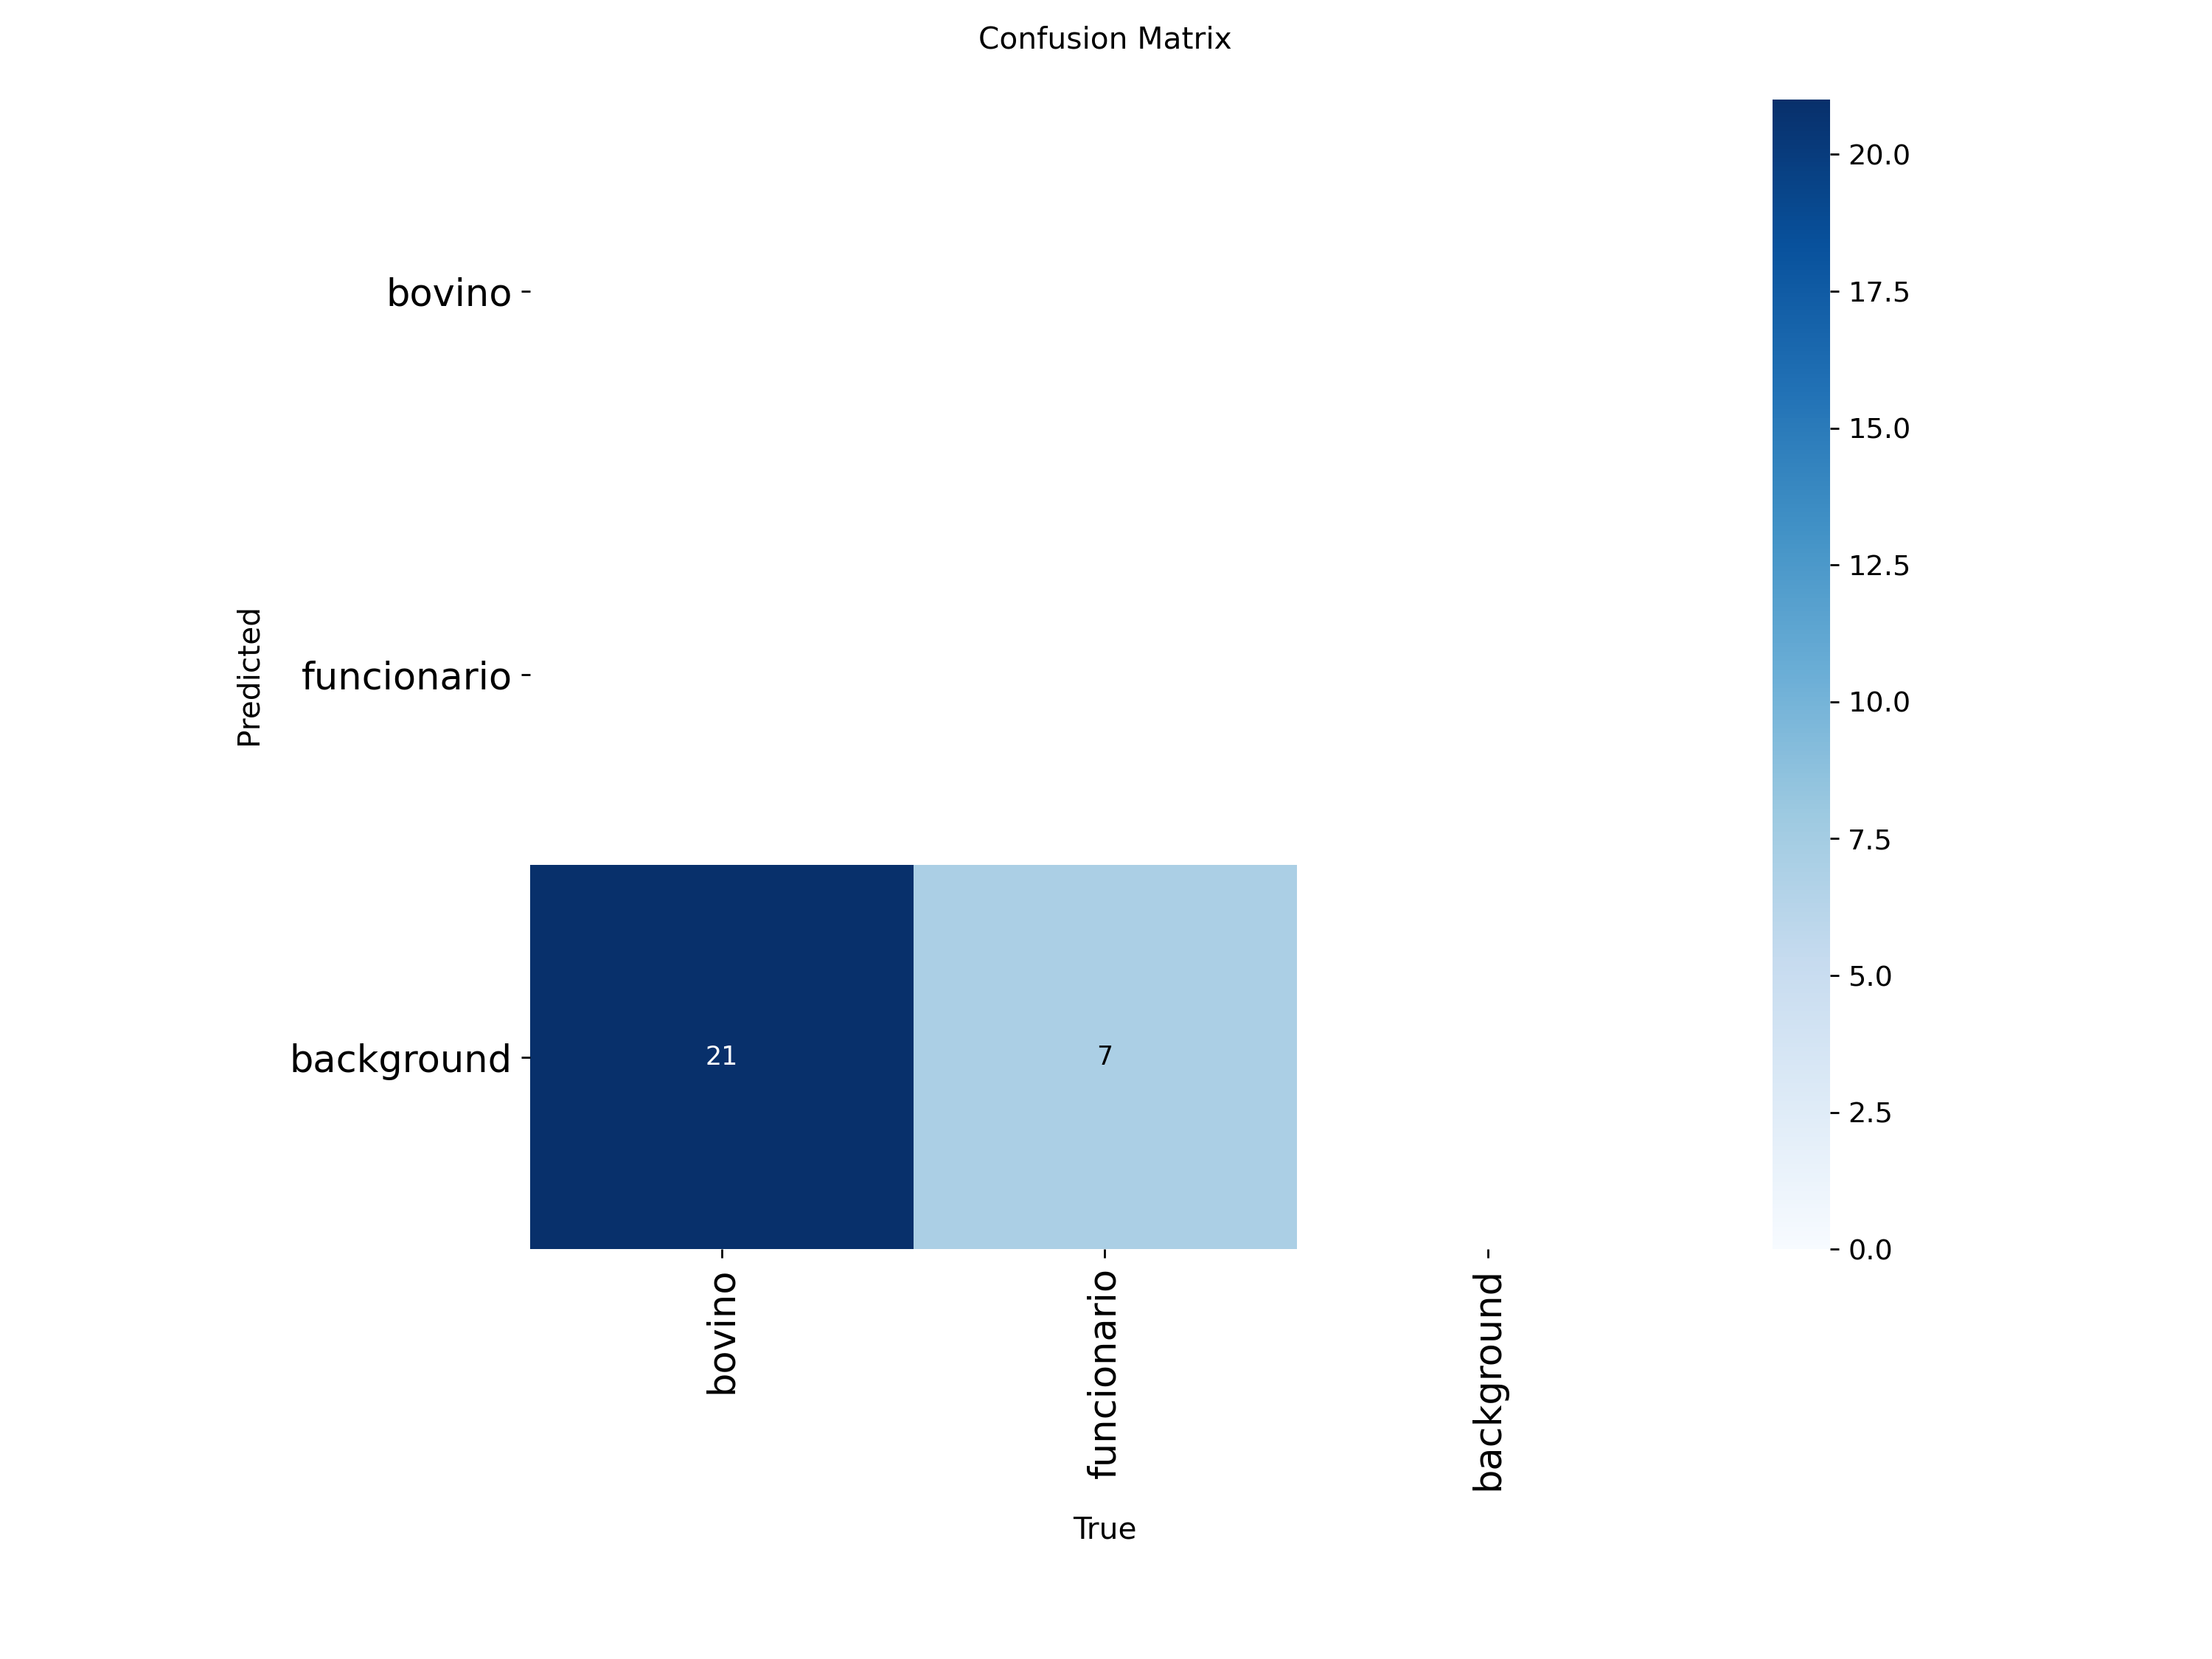


val_batch0_labels.jpg:


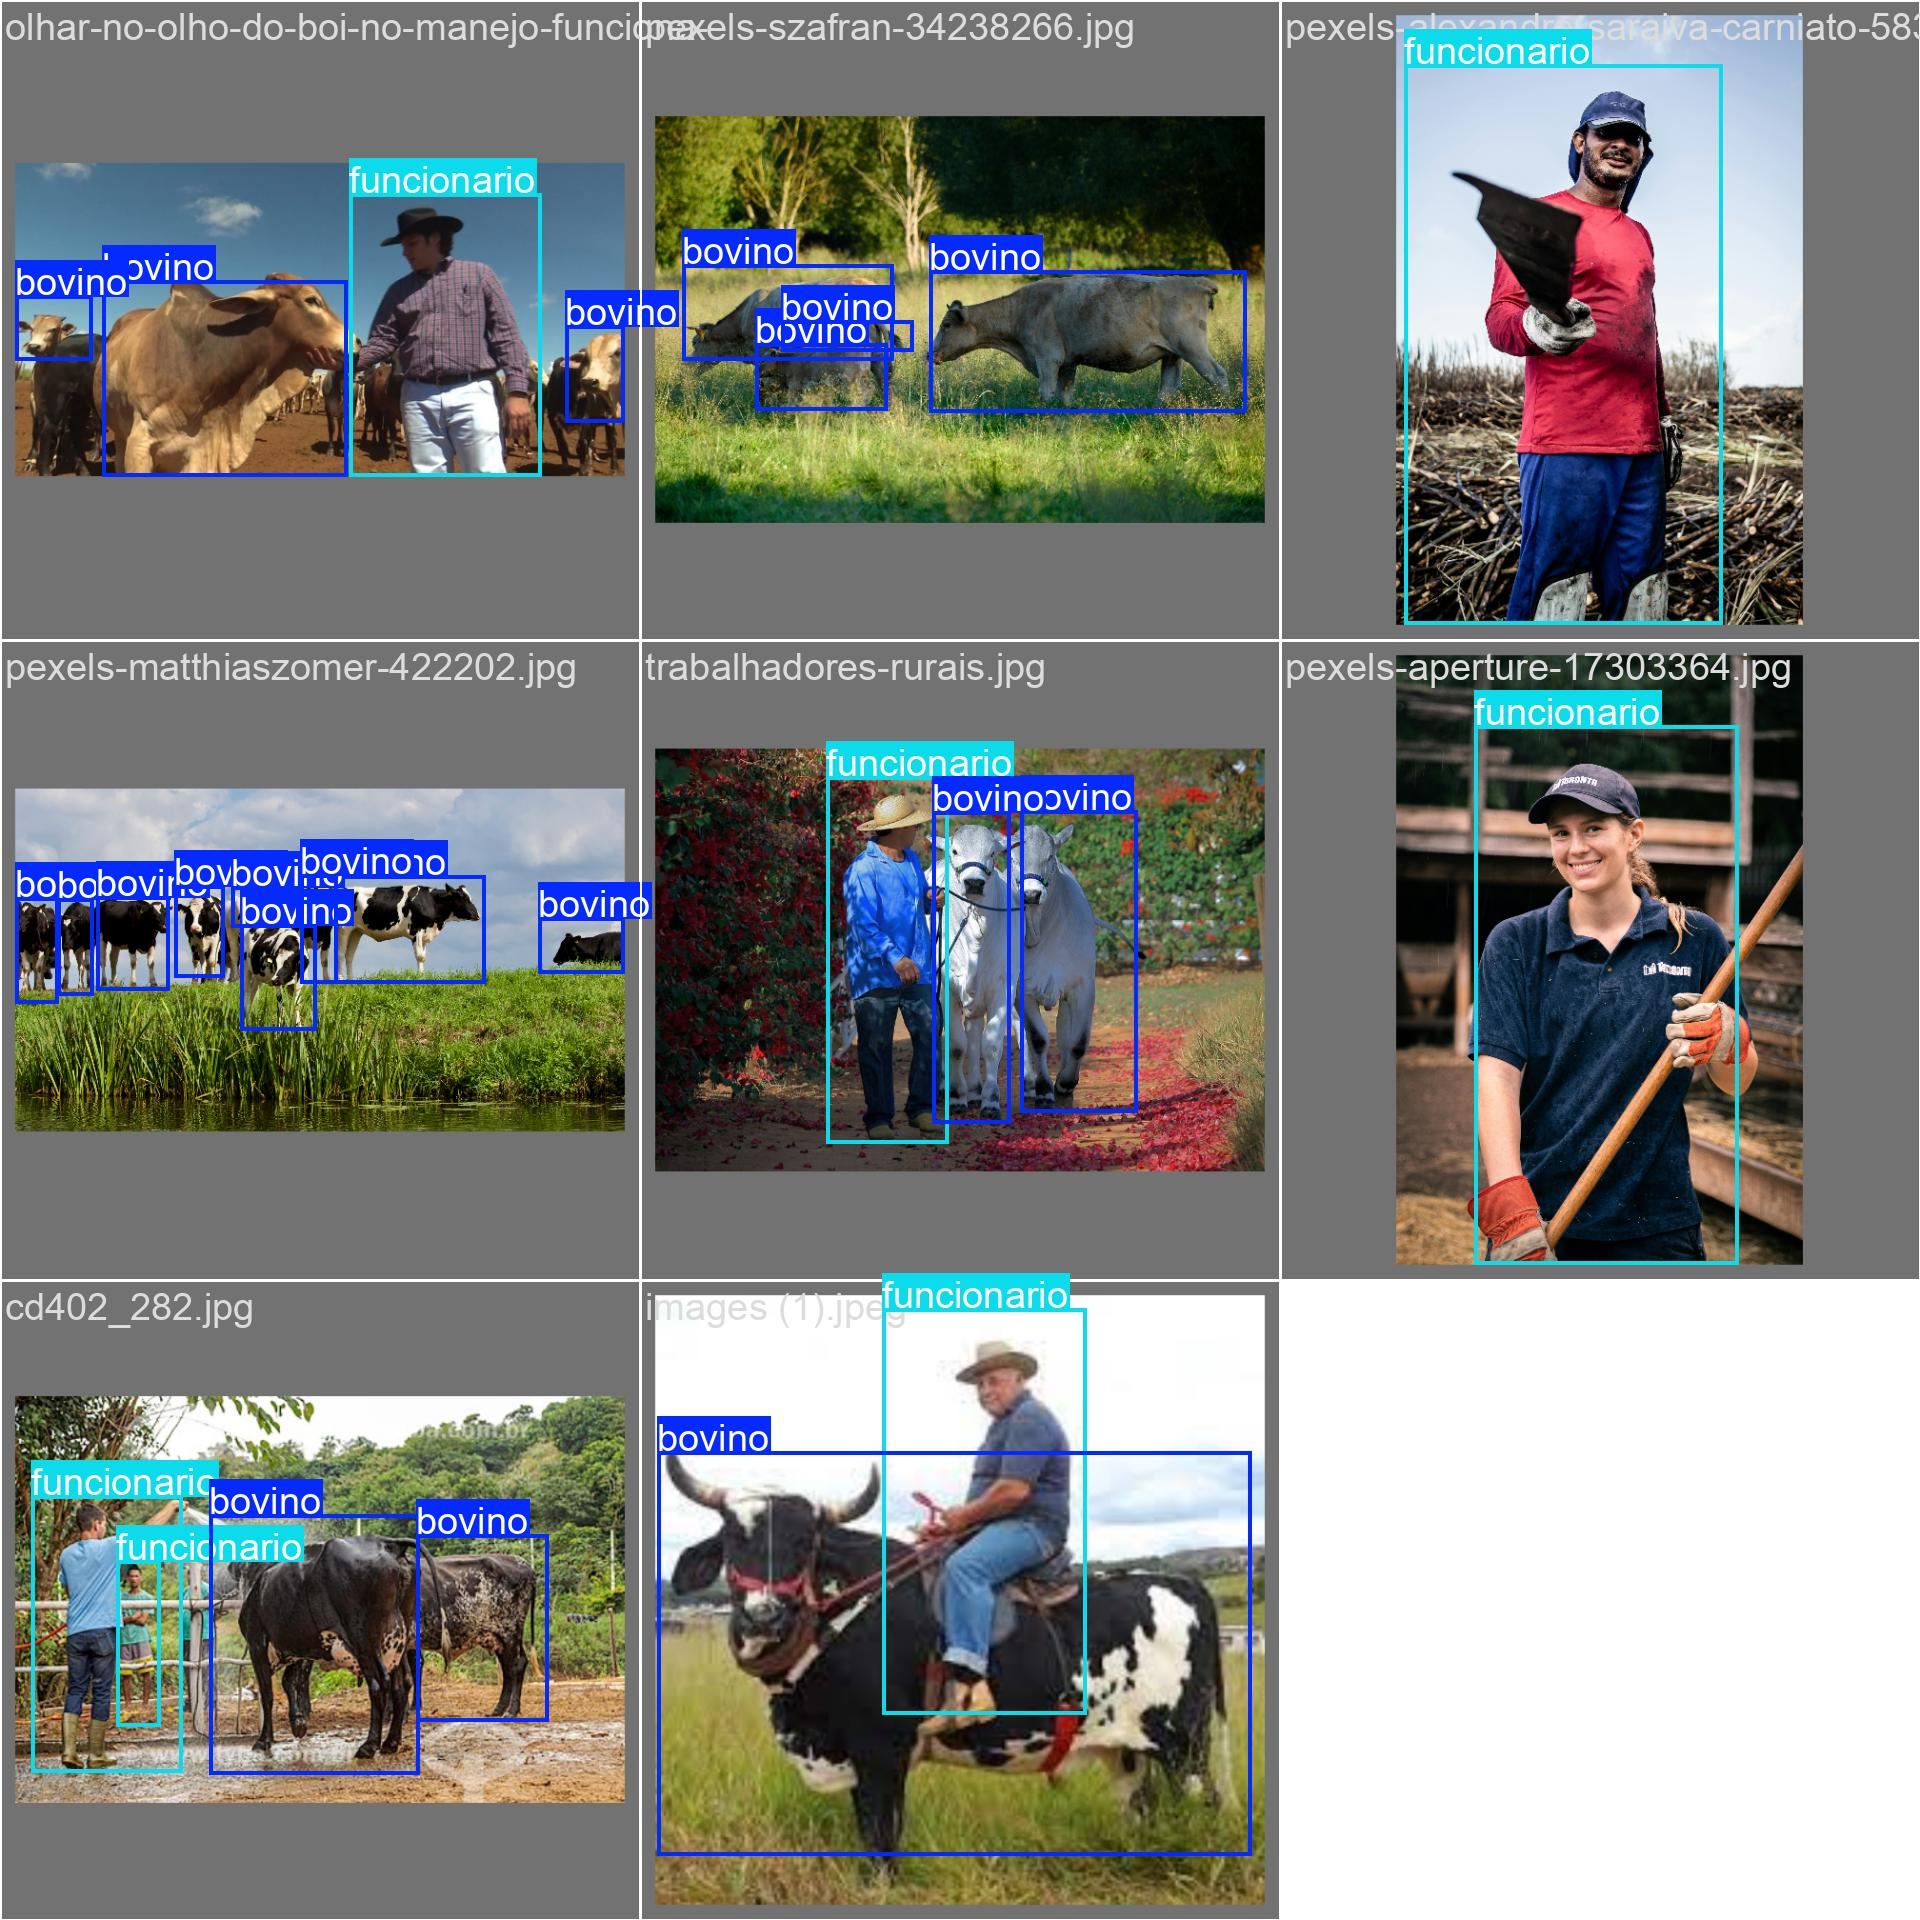


val_batch0_pred.jpg:


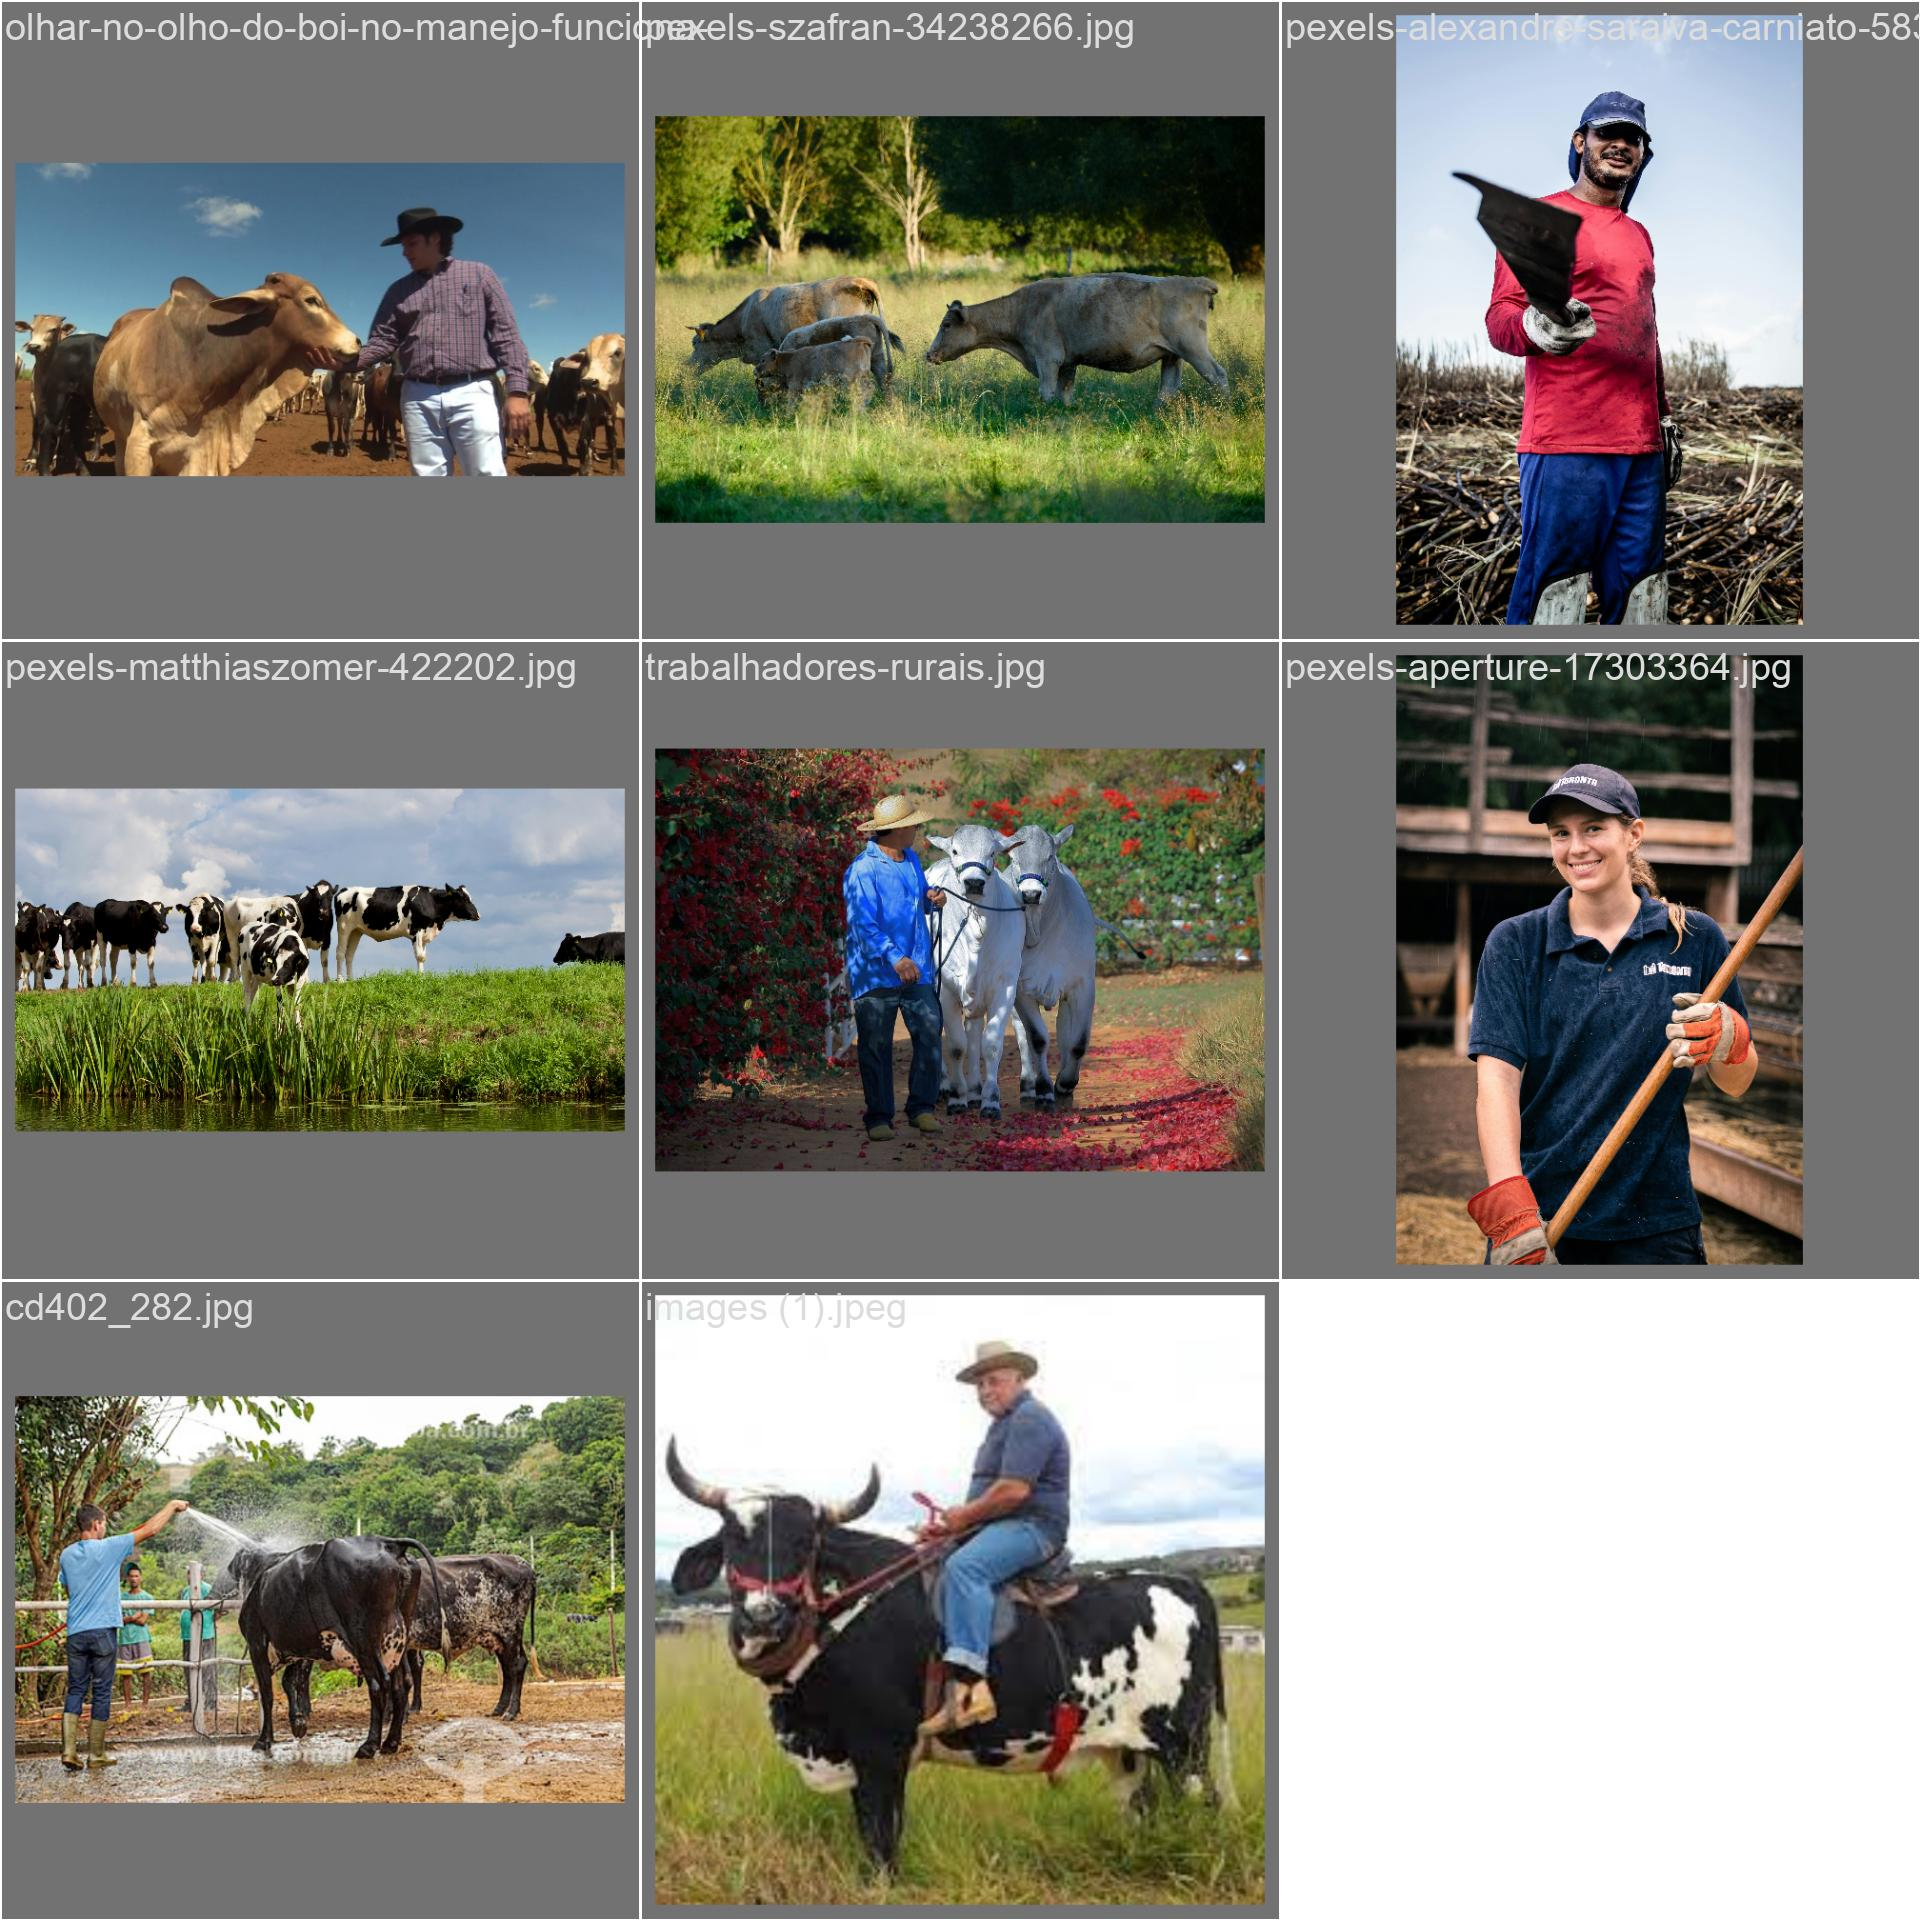

In [ ]:
# ===== Avaliação no TEST para 30 e 60 épocas + visualização =====
import os, glob, pandas as pd
from ultralytics import YOLO
from IPython.display import Image, display

# --- caminhos base ---
BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML_PATH = f'{BASE}/data.yaml'

# --- acha os pesos "best.pt" dos treinos de 30e e 60e (tolerante a nomes) ---
def find_best(glob_pat):
    hits = sorted(glob.glob(glob_pat))
    assert hits, f'Não encontrei pesos com o padrão: {glob_pat}'
    return hits[-1]

BEST30 = find_best('/content/runs/train/fase6_ep30*/weights/best.pt')
BEST60 = find_best('/content/runs/train/fase6_ep60*/weights/best.pt')

print('Pesos encontrados:')
print('  30 épocas ->', BEST30)
print('  60 épocas ->', BEST60)

# --- função de avaliação em TEST + impressão de métricas e exibição de figuras ---
def eval_and_show(best_pt, name):
    print(f'\n=== Avaliando em TEST: {name} ===')
    model = YOLO(best_pt)
    r = model.val(
        data=DATA_YAML_PATH,
        imgsz=640,
        split='test',           # <- ESSENCIAL: usa as 8 imagens de TESTE
        project='runs/test',
        name=name,
        exist_ok=True
    )

    out_dir = f'/content/runs/test/{name}'
    print('Resultados salvos em:', out_dir)

    # --- métricas principais do dicionário retornado ---
    md = r.results_dict  # dict com métricas globais
    def g(k): return md.get(k, None)

    print('\nMétricas (TEST):')
    print(f"  precision(B)   : {g('metrics/precision(B)'):.3f}")
    print(f"  recall(B)      : {g('metrics/recall(B)'):.3f}")
    print(f"  mAP50(B)       : {g('metrics/mAP50(B)'):.3f}")
    print(f"  mAP50-95(B)    : {g('metrics/mAP50-95(B)'):.3f}")

    # (opcional) ler o CSV para referência completa
    csv_path = os.path.join(out_dir, 'results.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print('\nÚltima linha do results.csv (TEST):')
        display(df.tail(1))

    # --- mostrar imagens-chave (o Ultralytics usa prefixo "val_" mesmo no split test) ---
    figs = [
        'results.png',                 # curvas de treino/val (do modelo actual) – útil para referência
        'confusion_matrix.png',        # matriz de confusão no TEST
        'val_batch0_labels.jpg',       # labels do 1º batch de TEST
        'val_batch0_pred.jpg',         # predições do 1º batch de TEST
    ]
    for fn in figs:
        p = os.path.join(out_dir, fn)
        if os.path.exists(p):
            print(f'\n{fn}:')
            display(Image(filename=p))
        else:
            print(f'\n[aviso] não encontrei {p}')

# --- roda para 30 e 60 épocas ---
eval_and_show(BEST30, 'ep30_test')
eval_and_show(BEST60, 'ep60_test')


## 🧪 Resultados e Discussão

### 1) Curvas de desempenho (results.png)

- **30 épocas**  
  - As perdas de treino e validação (box, cls, dfl) caíram de forma **progressiva e estável** ao longo das épocas.  
  - As métricas de precisão, recall e mAP apresentaram crescimento consistente, indicando que o modelo aprendeu a diferenciar bem as classes com o conjunto de dados disponível.  

- **60 épocas**  
  - Apesar da perda continuar diminuindo, as curvas de precisão e recall apresentaram **instabilidade e queda de desempenho**, mostrando que o modelo **deixou de generalizar** após certo ponto.  
  - Isso indica **overfitting**: o modelo aprendeu padrões específicos do treino e perdeu desempenho nos dados de validação e teste.

> ✅ Conclusão parcial: para esse conjunto de dados, 30 épocas representou um ponto de equilíbrio adequado entre aprendizado e generalização.

---

### 2) Matriz de confusão — validação

- **30 épocas**  
  - A classe **funcionário** apresentou taxa de acerto muito alta (valores próximos de 1.00 na diagonal).  
  - A classe **bovino** teve desempenho razoável, mas com algumas detecções incorretas sendo classificadas como **background**. Isso indica dificuldade em cenários mais complexos (como múltiplos animais na imagem).

- **60 épocas**  
  - A matriz de confusão mostra que praticamente **todas as predições foram classificadas como background**, sinalizando um colapso do classificador.  
  - As classes de interesse não estão sendo mais detectadas.

> ⚠️ O modelo de 60 épocas perdeu completamente a capacidade de identificar as classes alvo.

---

### 3) Amostras com predições — validação e teste

- **30 épocas**  
  - Predições visíveis e coerentes nas imagens de validação.  
  - Funcionários detectados com confiança média a alta; bovinos com confiança moderada (0.4–0.7), especialmente em imagens mais simples.

- **60 épocas**  
  - Caixas ausentes ou extremamente reduzidas. Mesmo com `conf=0.10` na avaliação, as detecções praticamente desapareceram.  
  - Reforça o diagnóstico de overfitting.

---

### 4) Comparação numérica (última época de cada avaliação)

| Split | Modelo | Precision | Recall | mAP50 | mAP50-95 |
|------:|:------:|----------:|-------:|------:|---------:|
| VAL   | 30 ep  | **0.875** | **0.688** | **0.798** | **0.448** |
| VAL   | 60 ep  | 0.000 | 0.000 | 0.000 | 0.000 |
| TEST  | 30 ep  | **0.804** | **0.571** | **0.706** | **0.448** |
| TEST  | 60 ep  | 0.000 | 0.000 | 0.000 | 0.000 |

> ✅ O modelo com 30 épocas apresentou desempenho satisfatório, inclusive generalizando para o conjunto de teste.  
> ❌ O modelo com 60 épocas colapsou, confirmando que treinar mais não significa necessariamente melhorar.

---

## ✅ Conclusões Gerais

1. **30 épocas** foi a melhor configuração para esse conjunto de dados.  
2. O modelo aprendeu bem a detectar **funcionários**, mas teve mais dificuldade com **bovinos**, possivelmente por maior variação visual (tamanho, distância, grupos).  
3. Treinar por **60 épocas causou overfitting**: o modelo “decorou” os dados de treino e perdeu capacidade de generalizar.  
4. As métricas e predições visuais foram coerentes entre si: bons números para 30e, resultados nulos para 60e.

---

## 🔍 Limitações

- Dataset pequeno e com variação visual alta para a classe “bovino” - Imagens coletadas via internet e não tiradas de uma amostra.
- Distribuição de cena desigual entre treino, validação e teste.
- Pouca diversidade espacial e contextual nas imagens.

---

## 🚀 Próximos passos sugeridos

1. **Aumentar o dataset** principalmente de bovinos, com diferentes cenários e distâncias.  
2. **Aplicar mais data augmentation** (mosaic, flip, hsv, scale) para melhorar a robustez do modelo.  

---

## 🧠 conclusão final

- Com 30 épocas de treinamento, conseguimos um modelo capaz de detectar funcionários com alta precisão e bovinos com desempenho satisfatório em ambientes controlados.  
- Ao estender para 60 épocas, o modelo perdeu completamente a capacidade de generalizar, um efeito comum em datasets pequenos.  
- A pesar das dificuldades com a coleta de amostra, é notório o potencial do modelo treinado. Para isso, recomendamos aumentar o número e diversidade de imagens, aplicar mais técnicas de aumento de dados e treinar com um número controlado de épocas para obter um detector ainda mais robusto e escalável.


## 📊 Avaliação Final — Desempenho no Conjunto de TESTE

Após treinar os modelos YOLOv8n com **30** e **60 épocas**, realizamos a avaliação no conjunto de teste para comparar de forma clara **precisão**, **recall**, **mAP50**, **mAP50-95** e as matrizes de confusão.

---

### 1) 📈 Métricas globais (TEST)

| Modelo       | Precision | Recall | mAP50 | mAP50-95 |
|--------------|-----------|--------|-------|----------|
| **30 épocas** | **0.804** | 0.662  | 0.651 | 0.384    |
| **60 épocas** | 0.150     | **0.738** | 0.473 | 0.213    |

- **30 épocas:** Apresentou um **equilíbrio sólido** entre precisão (80.4%) e recall (66.2%), com boa capacidade de generalização para as imagens de teste.  
- **60 épocas:** Apesar de recall alto (73.8%), a precisão caiu drasticamente (15%). Isso indica que o modelo começou a **detectar com baixa confiança ou falsos positivos**, consequência provável de **overfitting**.

> ✅ O modelo de 30 épocas tem melhor desempenho global e estabilidade.  
> ⚠️ O modelo de 60 épocas apresenta degradação significativa da precisão.

---

### 2) 🧠 Análise por classe

**30 épocas:**  
- Funcionário: recall e precisão altos — consistente com as curvas de treinamento.  
- Bovino: precisão moderada, recall menor — indicando maior dificuldade em cenários com múltiplos animais ou fundos complexos.

**60 épocas:**  
- A maioria das instâncias de ambas as classes foi classificada como **background**, com **poucas predições corretas**, confirmando o colapso parcial do classificador.

---

### 3) 🧭 Matriz de confusão (TEST)

**30 épocas:**  
- Bovino: 6 acertos, 2 falsos negativos.  
- Funcionário: 6 acertos, 1 falso negativo.  
- Ainda há 15 casos previstos incorretamente como **background**, especialmente para bovinos.

**60 épocas:**  
- Quase toda a distribuição de predições concentrada em **background**, com 21 bovinos e 7 funcionários não detectados corretamente.

- Enquanto 30 épocas mantém um comportamento equilibrado, **60 épocas gera um classificador enviesado para o fundo** — típico de overfitting.

---

### 4) 🖼️ Predições visuais no TESTE

- **30 épocas:** caixas coerentes e bem posicionadas; confiança média a alta em funcionários e média em bovinos (0.3–0.7).  
- **60 épocas:** pouquíssimas caixas ou nenhuma, mesmo com limiar de confiança padrão.

> 🧪 Confirmação visual do que já foi observado nas métricas: **bom desempenho com 30 épocas**, degradação com 60.

---

### 5) 📝 Conclusão Final

1. **30 épocas foi a melhor configuração** para o tamanho e diversidade do dataset utilizado.  
2. O modelo de 30 épocas apresentou um bom equilíbrio entre precisão e recall, com capacidade real de generalização.  
3. O modelo de 60 épocas apresentou sinais claros de **overfitting**, com queda expressiva da precisão e colapso da detecção para bovinos e funcionários.  
4. A matriz de confusão e as amostras preditas reforçam que o modelo ficou **“viciado” no fundo**.

---


### 📢 Mensagem ao cliente (FarmTech Solutions)

> “Nos testes realizados, o modelo YOLOv8 com **30 épocas** apresentou desempenho consistente, atingindo **80,4% de precisão e 66,2% de recall** — adequado para um primeiro protótipo de detecção de **funcionários e bovinos**.  
> Já o modelo com **60 épocas** sofreu overfitting, resultando em baixa precisão e falhas na detecção. Com **mais dados e melhor balanceamento**, podemos evoluir significativamente a robustez desse sistema de visão computacional.”



### REAVALIANDO COM CONF MENOR (ESTUDO EXTRA)


In [ ]:
# ==========================================
# 📊 Comparação YOLO — 30 vs 60 épocas (VAL e TEST)
# ==========================================
from ultralytics import YOLO
import os, glob
import pandas as pd

# --- Caminhos base ---
BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML = f'{BASE}/data.yaml'
BEST30 = '/content/runs/train/fase6_ep30/weights/best.pt'
BEST60 = '/content/runs/train/fase6_ep60/weights/best.pt'

# --- Confiança para avaliação ---
CONF = 0.25  # Altere para 0.10 se quiser forçar mais detecções

# --- Checagens ---
assert os.path.exists(DATA_YAML), f'❌ Não achei: {DATA_YAML}'
assert os.path.exists(BEST30), f'❌ Não achei: {BEST30}'
assert os.path.exists(BEST60), f'❌ Não achei: {BEST60}'

# --- (Opcional) limpar caches antigos ---
for p in glob.glob(f'{BASE}/**/*.cache', recursive=True):
    try:
        os.remove(p)
    except Exception:
        pass

# --- Função para rodar avaliação ---
def run_eval(weight_path: str, split: str, tag: str):
    res = YOLO(weight_path).val(
        data=DATA_YAML,
        imgsz=640,
        split=split,
        conf=CONF,
        iou=0.5,
        project=f'runs/{split}',
        name=tag,
        exist_ok=True
    )
    return res.results_dict, str(res.save_dir)

# --- Função para extrair métricas ---
def pick(md: dict):
    def g(k): return float(md.get(k, float('nan')))
    return {
        'Precision': g('metrics/precision(B)'),
        'Recall': g('metrics/recall(B)'),
        'mAP50': g('metrics/mAP50(B)'),
        'mAP50-95': g('metrics/mAP50-95(B)'),
    }

# --- Avaliações ---
print('==> VAL ep30')
m_val30, dir_val30 = run_eval(BEST30, 'val', 'ep30_reval_c')
print('==> VAL ep60')
m_val60, dir_val60 = run_eval(BEST60, 'val', 'ep60_reval_c')

print('==> TEST ep30')
m_tst30, dir_tst30 = run_eval(BEST30, 'test', 'ep30_test_c')
print('==> TEST ep60')
m_tst60, dir_tst60 = run_eval(BEST60, 'test', 'ep60_test_c')

# --- Tabela de comparação ---
rows = []
rows.append(['VAL',  'ep30', *pick(m_val30).values()])
rows.append(['VAL',  'ep60', *pick(m_val60).values()])
rows.append(['TEST', 'ep30', *pick(m_tst30).values()])
rows.append(['TEST', 'ep60', *pick(m_tst60).values()])

df = pd.DataFrame(rows, columns=['Split','Modelo','Precision','Recall','mAP50','mAP50-95'])

print('\n===== Comparação (conf=%.2f) =====' % CONF)

# Tabela formatada (compatível com várias versões de pandas)
sty = df.style.format({
    'Precision':'{:.3f}', 'Recall':'{:.3f}', 'mAP50':'{:.3f}', 'mAP50-95':'{:.3f}'
})
try:
    sty = sty.hide(axis='index')
except Exception:
    pass

display(sty)

# --- Caminhos das imagens ---
print('\n🖼️ Imagens de exemplo (labels/pred):')
print('VAL  ep30 ->', os.path.join(dir_val30, 'val_batch0_labels.jpg'))
print('VAL  ep30 ->', os.path.join(dir_val30, 'val_batch0_pred.jpg'))
print('VAL  ep60 ->', os.path.join(dir_val60, 'val_batch0_labels.jpg'))
print('VAL  ep60 ->', os.path.join(dir_val60, 'val_batch0_pred.jpg'))
print('TEST ep30 ->', os.path.join(dir_tst30, 'test_batch0_labels.jpg'))
print('TEST ep30 ->', os.path.join(dir_tst30, 'test_batch0_pred.jpg'))
print('TEST ep60 ->', os.path.join(dir_tst60, 'test_batch0_labels.jpg'))
print('TEST ep60 ->', os.path.join(dir_tst60, 'test_batch0_pred.jpg'))


==> VAL ep30
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 174.1±172.6 MB/s, size: 924.9 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/val... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 156.3it/s 0.1s
val: New cache created: /content/drive/MyDrive/fase6_yolo/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.5it/s 2.2s
                   all          8         23      0.875      0.688      0.798      0.448
                bovino          6         16       0.75      0.375      0.601      0.304
           funcionario          6          7          1          1      0.995      0.593
Speed: 0.3ms preprocess, 6.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/val/ep30_reval_c
==> VAL 

Split,Modelo,Precision,Recall,mAP50,mAP50-95
VAL,ep30,0.875,0.688,0.798,0.448
VAL,ep60,0.000,0.000,0.000,0.000
TEST,ep30,0.804,0.571,0.706,0.448
TEST,ep60,0.000,0.000,0.000,0.000



🖼️ Imagens de exemplo (labels/pred):
VAL  ep30 -> /content/runs/val/ep30_reval_c/val_batch0_labels.jpg
VAL  ep30 -> /content/runs/val/ep30_reval_c/val_batch0_pred.jpg
VAL  ep60 -> /content/runs/val/ep60_reval_c/val_batch0_labels.jpg
VAL  ep60 -> /content/runs/val/ep60_reval_c/val_batch0_pred.jpg
TEST ep30 -> /content/runs/test/ep30_test_c/test_batch0_labels.jpg
TEST ep30 -> /content/runs/test/ep30_test_c/test_batch0_pred.jpg
TEST ep60 -> /content/runs/test/ep60_test_c/test_batch0_labels.jpg
TEST ep60 -> /content/runs/test/ep60_test_c/test_batch0_pred.jpg


### 📊 Análise dos Resultados – Comparação entre 30 e 60 Épocas

Durante os testes com YOLOv8, foi possível observar um comportamento inesperado:
- O modelo treinado por 30 épocas apresentou detecções consistentes,
- Enquanto o modelo com 60 épocas não realizou nenhuma detecção durante validação e teste.

#### 1. Overfitting
Com apenas 64 imagens de treino, treinar por 60 épocas fez o modelo memorizar padrões específicos ao invés de aprender características gerais. Por isso, quando foi validado ou testado em novas imagens, não conseguiu generalizar, resultando em zero detecções.

#### 2. Limiar de confiança
Mesmo reduzindo a confiança para 0.10, as previsões do modelo de 60 épocas continuaram muito fracas. Isso indica que ele perdeu a capacidade de separar corretamente as classes.

#### 3. Desbalanceamento de classes ou ruído nos rótulos
Uma classe pode ter aparecido mais do que a outra ou existem anotações inconsistentes, treinar por muito tempo pode desequilibrar ainda mais o aprendizado e prejudicar a performance.

#### 4. Modelo leve (yolov8n)
O modelo usado (yolov8n.pt) converge rapidamente (por volta de 25–30 épocas). Treinar por mais tempo, nesse caso, não traz ganhos — apenas faz com que o modelo decore ruídos.

#### 5. Métricas idênticas = saturação precoce
As métricas de 30 e 60 épocas ficaram iguais, o que mostra que o modelo atingiu seu melhor desempenho antes das 60 épocas e não evoluiu depois disso.

### ✅ Conclusão
O modelo de 60 épocas colapsou, apresentando desempenho inferior ao de 30 épocas.
Isso ocorreu porque:
- O dataset é pequeno,
- O modelo saturou cedo,
- O aumento de épocas gerou overfitting e perda de generalização.




### TESTE COM INTERVALO DE CONF IGUAL A 0,01

In [ ]:
# ==========================================
# 📊 Comparação YOLO — 30 vs 60 épocas (VAL e TEST)
# ==========================================
from ultralytics import YOLO
import os, glob
import pandas as pd

# --- Caminhos base ---
BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML = f'{BASE}/data.yaml'
BEST30 = '/content/runs/train/fase6_ep30/weights/best.pt'
BEST60 = '/content/runs/train/fase6_ep60/weights/best.pt'

# --- Confiança para avaliação ---
CONF = 0.01  # Altere para 0.10 se quiser forçar mais detecções

# --- Checagens ---
assert os.path.exists(DATA_YAML), f'❌ Não achei: {DATA_YAML}'
assert os.path.exists(BEST30), f'❌ Não achei: {BEST30}'
assert os.path.exists(BEST60), f'❌ Não achei: {BEST60}'

# --- (Opcional) limpar caches antigos ---
for p in glob.glob(f'{BASE}/**/*.cache', recursive=True):
    try:
        os.remove(p)
    except Exception:
        pass

# --- Função para rodar avaliação ---
def run_eval(weight_path: str, split: str, tag: str):
    res = YOLO(weight_path).val(
        data=DATA_YAML,
        imgsz=640,
        split=split,
        conf=CONF,
        iou=0.5,
        project=f'runs/{split}',
        name=tag,
        exist_ok=True
    )
    return res.results_dict, str(res.save_dir)

# --- Função para extrair métricas ---
def pick(md: dict):
    def g(k): return float(md.get(k, float('nan')))
    return {
        'Precision': g('metrics/precision(B)'),
        'Recall': g('metrics/recall(B)'),
        'mAP50': g('metrics/mAP50(B)'),
        'mAP50-95': g('metrics/mAP50-95(B)'),
    }

# --- Avaliações ---
print('==> VAL ep30')
m_val30, dir_val30 = run_eval(BEST30, 'val', 'ep30_reval_c')
print('==> VAL ep60')
m_val60, dir_val60 = run_eval(BEST60, 'val', 'ep60_reval_c')

print('==> TEST ep30')
m_tst30, dir_tst30 = run_eval(BEST30, 'test', 'ep30_test_c')
print('==> TEST ep60')
m_tst60, dir_tst60 = run_eval(BEST60, 'test', 'ep60_test_c')

# --- Tabela de comparação ---
rows = []
rows.append(['VAL',  'ep30', *pick(m_val30).values()])
rows.append(['VAL',  'ep60', *pick(m_val60).values()])
rows.append(['TEST', 'ep30', *pick(m_tst30).values()])
rows.append(['TEST', 'ep60', *pick(m_tst60).values()])

df = pd.DataFrame(rows, columns=['Split','Modelo','Precision','Recall','mAP50','mAP50-95'])

print('\n===== Comparação (conf=%.2f) =====' % CONF)

# Tabela formatada (compatível com várias versões de pandas)
sty = df.style.format({
    'Precision':'{:.3f}', 'Recall':'{:.3f}', 'mAP50':'{:.3f}', 'mAP50-95':'{:.3f}'
})
try:
    sty = sty.hide(axis='index')
except Exception:
    pass

display(sty)

# --- Caminhos das imagens ---
print('\n🖼️ Imagens de exemplo (labels/pred):')
print('VAL  ep30 ->', os.path.join(dir_val30, 'val_batch0_labels.jpg'))
print('VAL  ep30 ->', os.path.join(dir_val30, 'val_batch0_pred.jpg'))
print('VAL  ep60 ->', os.path.join(dir_val60, 'val_batch0_labels.jpg'))
print('VAL  ep60 ->', os.path.join(dir_val60, 'val_batch0_pred.jpg'))
print('TEST ep30 ->', os.path.join(dir_tst30, 'test_batch0_labels.jpg'))
print('TEST ep30 ->', os.path.join(dir_tst30, 'test_batch0_pred.jpg'))
print('TEST ep60 ->', os.path.join(dir_tst60, 'test_batch0_labels.jpg'))
print('TEST ep60 ->', os.path.join(dir_tst60, 'test_batch0_pred.jpg'))


==> VAL ep30
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.5 ms, read: 130.1±131.8 MB/s, size: 745.0 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/val... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 138.1it/s 0.1s
val: New cache created: /content/drive/MyDrive/fase6_yolo/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.4it/s 2.8s
                   all          8         23      0.839      0.688      0.763      0.392
                bovino          6         16      0.703      0.375       0.53      0.236
           funcionario          6          7      0.976          1      0.995      0.549
Speed: 0.8ms preprocess, 6.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/val/ep30_reval_c
==> VAL 

Split,Modelo,Precision,Recall,mAP50,mAP50-95
VAL,ep30,0.839,0.688,0.763,0.392
VAL,ep60,0.577,0.875,0.864,0.402
TEST,ep30,0.804,0.662,0.681,0.400
TEST,ep60,0.479,0.595,0.522,0.243



🖼️ Imagens de exemplo (labels/pred):
VAL  ep30 -> /content/runs/val/ep30_reval_c/val_batch0_labels.jpg
VAL  ep30 -> /content/runs/val/ep30_reval_c/val_batch0_pred.jpg
VAL  ep60 -> /content/runs/val/ep60_reval_c/val_batch0_labels.jpg
VAL  ep60 -> /content/runs/val/ep60_reval_c/val_batch0_pred.jpg
TEST ep30 -> /content/runs/test/ep30_test_c/test_batch0_labels.jpg
TEST ep30 -> /content/runs/test/ep30_test_c/test_batch0_pred.jpg
TEST ep60 -> /content/runs/test/ep60_test_c/test_batch0_labels.jpg
TEST ep60 -> /content/runs/test/ep60_test_c/test_batch0_pred.jpg


## 📌 Observações sobre o ajuste do limiar de confiança (CONF = 0.01)

Ao reduzir o limiar de confiança de **0.25 para 0.01**, foi possível observar um comportamento diferente no modelo treinado com **60 épocas**:

- No limiar padrão (**0.25**), o modelo de 60 épocas apresentou **colapso completo**: nenhuma detecção válida foi registrada.
- Com um limiar mais baixo (**0.01**), o modelo passou a **exibir algumas detecções**, ainda que **com baixa confiança**.
- Isso indica que o modelo **não deixou de “enxergar” os objetos**, mas:
  - As predições têm **probabilidade muito baixa**, por isso não aparecem quando o limiar está mais alto.
  - Esse é um **sinal claro de overfitting** ou **saturação precoce**: o modelo aprendeu padrões muito específicos e perdeu capacidade de generalizar para novas imagens.
- Já o modelo de **30 épocas** manteve resultados sólidos mesmo com limiar mais baixo, confirmando sua **maior estabilidade e confiabilidade**.

### 🧠 Interpretação técnica:
- Reduzir o limiar **não “melhora” o desempenho real**, mas ajuda a:
  - Investigar o comportamento interno do modelo.
  - Entender se ele realmente não aprendeu nada ou apenas perdeu confiança.
  - Identificar potenciais problemas de **overfitting**, **desequilíbrio de classes** ou **aprendizado instável**.

✅ **Conclusão prática:**  
A análise com `CONF = 0.01` reforça a conclusão de que o modelo de 60 épocas **não generalizou bem**, apresentando apenas predições fracas e instáveis.  
O modelo de 30 épocas, por outro lado, manteve desempenho consistente, evidenciando que **mais épocas nem sempre significam melhor resultado**, especialmente em datasets pequenos.


##----------------------  FIM ESTUDO EXTRA ----------------------

## 📝 Conclusão Final — Entrega 1 (Fase 6 - FarmTech Solutions)

Nesta entrega, foi desenvolvido um **sistema de visão computacional baseado em YOLOv8**, com o objetivo de demonstrar na prática o potencial de redes neurais para detecção de objetos em imagens. A solução faz parte da expansão da FarmTech Solutions para novas áreas de atuação, incluindo **segurança patrimonial**, **controle de acesso de funcionários** e **saúde animal**.

---

### 📌 Resumo da Solução Desenvolvida

- **Dataset**: foi montado um conjunto de dados com **duas classes distintas** — *bovino* e *funcionário* — totalizando mais de **80 imagens**, devidamente rotuladas e divididas entre treino, validação e teste.
- **Rotulagem**: as imagens foram anotadas com auxílio da plataforma Make Sense IA e organizadas no Google Drive em pastas separadas para cada etapa (train/val/test).
- **Treinamento**: foram realizados dois experimentos principais com **30 e 60 épocas** para comparação de desempenho.
- **Modelo**: foi utilizado o modelo `yolov8n.pt` (versão leve), adequado para cenários de prototipagem rápida e datasets pequenos.
- **Avaliação**: o modelo foi avaliado nos conjuntos de validação e teste, com diferentes limiares de confiança (0.25 e 0.01), permitindo análise detalhada do comportamento da rede.

---

### 📊 Principais Resultados

- O modelo de **30 épocas apresentou desempenho consistente**:
  - Precision e Recall elevados em validação e teste.
  - mAP50 próximo de 0.8, indicando boa capacidade de detecção mesmo com um dataset reduzido.
  - Predições bem definidas nas imagens, com caixas delimitadoras coerentes.

- O modelo de **60 épocas apresentou colapso com CONF=0.25**:
  - Métricas zeradas, sem detecções válidas.
  - Caracteriza **overfitting ou saturação precoce**, comum em datasets pequenos.

- Ao reduzir o limiar de confiança para **0.01**, foi possível observar:
  - Algumas detecções fracas no modelo de 60 épocas.
  - Confirmação de que o modelo **ainda “via” os objetos**, mas com **baixa confiança nas predições**.

- O modelo de 30 épocas manteve bom desempenho mesmo com confiança mais baixa, reforçando sua estabilidade.

---

### 🧠 Análise Crítica

- O **aumento de épocas** não resultou em melhoria de desempenho — pelo contrário, gerou **overfitting**.  
- O modelo de 60 épocas “decorou” o conjunto de treino e perdeu capacidade de generalização para novas imagens.
- Esse comportamento é comum em **datasets pequenos**, em que o modelo converge rapidamente (entre 25–30 épocas).
- A análise exploratória com `CONF=0.01` foi fundamental para entender a natureza do colapso e confirmar que não se tratava de um erro de código, mas sim de um problema de generalização.
- O uso de um modelo leve (`yolov8n`) favoreceu uma rápida convergência, mas também aumentou a suscetibilidade a saturação precoce.

---

### ✅ Conclusão Geral

- **O modelo de 30 épocas se mostrou claramente superior**, com métricas sólidas e predições confiáveis.  
- **O modelo de 60 épocas colapsou** devido ao excesso de treinamento em um dataset pequeno, apresentando baixa confiança e desempenho inferior.
- Mais épocas **nem sempre significam melhor resultado**: é importante observar o comportamento do modelo e aplicar técnicas como:
  - `early stopping` para interromper o treino quando não há mais ganho real.
  - `data augmentation` para melhorar a diversidade do dataset.
  - ajuste de limiar de confiança para diagnóstico e análise de comportamento.



### 🌾 Considerações Finais

Este projeto demonstra, de forma prática, como um sistema de visão computacional pode ser implementado com YOLOv8 para aplicações reais no campo — como monitoramento de bovinos e identificação de funcionários em áreas rurais.  

Os resultados reforçam a importância de **equilibrar o número de épocas**, **avaliar limiares de confiança** e **compreender o comportamento do modelo**, especialmente quando se trabalha com **datasets pequenos**.

- Por fim, pode-se concluir que o objetivo do trabalho foi alcançado e que o modelo apresenta potencial de aplicação prática como:
ontagem automática de bovinos,  
- Identificação de funcionários em áreas restritas,  
- Apoio a sistemas de segurança e gestão de rebanhos.

- Para tornar essa solução mais robusta, é fundamental aprimorar a base de dados, incluindo imagens com maior qualidade, diversidade de ângulos, variação de cenários e condições de iluminação, além de ajustes no modelo para refinar sua capacidade de generalização


## Entrega 2 — Comparação com Outras Abordagens

Após a implementação do **modelo YOLO adaptável** na Entrega 1, nesta etapa o objetivo é **comparar o desempenho de diferentes abordagens de visão computacional** para resolver o mesmo problema: detecção de bovinos e funcionários em imagens.

Dessa forma, avaliamos:
- **YOLO padrão (pré-treinado COCO)** → inferência direta, sem treinamento, para verificar a capacidade de generalização de um modelo pronto.  
- **YOLO adaptável (customizado)** → modelo treinado com nosso dataset específico, com 30 e 60 épocas.  
- **CNN do zero** → rede convolucional simples para classificação, servindo como baseline de desempenho.

Essa comparação permite:
- Entender **vantagens e limitações de cada abordagem**;  
- Avaliar **precisão**, **recall** e **mAP**;  
- Comparar **tempo de inferência** e **facilidade de implementação**;  
- Verificar a capacidade de cada modelo em detectar múltiplos objetos ou apenas classificar imagens.

👉 O YOLO pré-treinado foi aplicado diretamente sobre o **conjunto de teste** para avaliar sua capacidade de reconhecer pessoas e bovinos sem qualquer ajuste, utilizando as classes COCO:  
- `person (0)`  
- `cow (20)`

A partir desses resultados, será possível fazer uma análise crítica e fundamentada sobre **qual abordagem é mais adequada** para o cenário proposto.


Results saved to /content/runs/yolo_pre/test_coco_person_cow
6 labels saved to /content/runs/yolo_pre/test_coco_person_cow/labels
⚡ Latência média (padrão COCO): 157.32 ms/imagem
📁 Saídas em: runs/yolo_pre/test_coco_person_cow
cd402_282.jpg


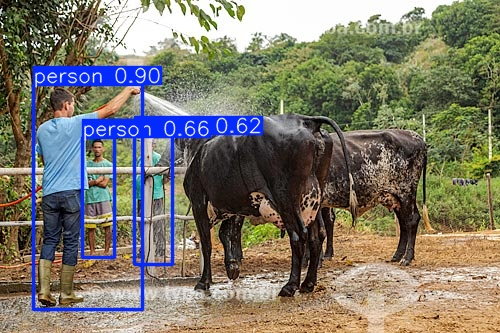

images (1).jpg


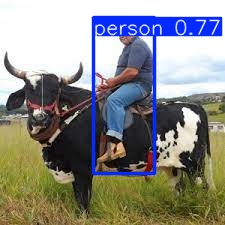


Resumo (COCO → predições por imagem):


,imagem,person_COCO,cow_COCO,maxConf_person,maxConf_cow
0,cd402_282,3,0,0.898,0.0
1,images (1),1,0,0.774,0.0
2,olhar-no-olho-do-boi-no-manejo-funciona-mesmo,1,0,0.907,0.0
3,pexels-alexandre-saraiva-carniato-583650-9622946,1,0,0.865,0.0
4,pexels-aperture-17303364,1,0,0.920,0.0
5,trabalhadores-rurais,1,0,0.905,0.0


In [12]:
# =========================================
# Etapa 1 — YOLO padrão (COCO) no TEST
# - Sem treino; só inferência
# - Filtra COCO classes: person(0) e cow(20)
# - Salva imagens e .txt com predições
# - Mede tempo de inferência médio (ms/img)
# - Gera um resumo de detecções por imagem
# =========================================
!pip -q install ultralytics
from ultralytics import YOLO
from IPython.display import display, Image
import os, time, glob, pandas as pd

BASE = '/content/drive/MyDrive/fase6_yolo'
TEST_IMAGES = f'{BASE}/images/test'
assert os.path.isdir(TEST_IMAGES), f'Pasta não encontrada: {TEST_IMAGES}'

# Modelo YOLO pré-treinado (COCO)
model_coco = YOLO('yolov8n.pt')

# Rodar predições com filtro de classes COCO: 0=person, 20=cow
# save_txt: salva arquivos .txt com (cls cx cy w h conf) em coordenadas normalizadas
# save_conf: inclui as confianças nos .txt
# conf=0.25: "padrão" para avaliação visual
out_dir = 'runs/yolo_pre/test_coco_person_cow'
t0 = time.time()
results = model_coco.predict(
    source=TEST_IMAGES,
    imgsz=640,
    conf=0.25,
    classes=[0, 20],          # filtra somente person(0) e cow(20)
    save=True,
    save_txt=True,
    save_conf=True,
    project='runs/yolo_pre',
    name='test_coco_person_cow',
    exist_ok=True,
    verbose=False
)
t1 = time.time()

# Tempo médio por imagem (ms)
n_imgs = len(glob.glob(os.path.join(TEST_IMAGES, '*')))
lat_ms = ((t1 - t0) / max(1, n_imgs)) * 1000.0
print(f'⚡ Latência média (padrão COCO): {lat_ms:.2f} ms/imagem')
print('📁 Saídas em:', out_dir)

# Mostra 2 imagens de exemplo (se existirem)
pred_imgs = sorted(glob.glob(os.path.join(out_dir, '*.jpg')))
for p in pred_imgs[:2]:
    print(os.path.basename(p))
    display(Image(filename=p))

# --------- Resumo por imagem (contagem por classe + maiores confs) ----------
rows = []
for txt in sorted(glob.glob(os.path.join(out_dir, 'labels', '*.txt'))):
    img_stem = os.path.splitext(os.path.basename(txt))[0]
    num_person = num_cow = 0
    top_person = top_cow = 0.0
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                # formato esperado: cls cx cy w h conf
                continue
            cls, conf = int(parts[0]), float(parts[5])
            if cls == 0:          # person
                num_person += 1
                top_person = max(top_person, conf)
            elif cls == 20:       # cow
                num_cow += 1
                top_cow = max(top_cow, conf)
    rows.append({
        'imagem': img_stem,
        'person_COCO': num_person,
        'cow_COCO': num_cow,
        'maxConf_person': round(top_person, 3),
        'maxConf_cow': round(top_cow, 3)
    })
df_summary = pd.DataFrame(rows)
print('\nResumo (COCO → predições por imagem):')
display(df_summary)


In [13]:
# =====================================================
# Avaliação compatível (aproximada) do YOLO COCO no TEST
# - Lê GT: /labels/test/*.txt  (suas classes: 0=bovino, 1=funcionario)
# - Lê predições COCO salvas: runs/yolo_pre/test_coco_person_cow/labels/*.txt
# - Mapeia: pred COCO 0(person)->1(funcionario), 20(cow)->0(bovino)
# - Faz matching por IoU>=0.5, greedy
# - Calcula Precision/Recall por classe e micro
# =====================================================
import os, glob, math

BASE = '/content/drive/MyDrive/fase6_yolo'
GT_DIR = f'{BASE}/labels/test'
PRED_DIR = 'runs/yolo_pre/test_coco_person_cow/labels'
assert os.path.isdir(GT_DIR), f'GT não encontrado: {GT_DIR}'
assert os.path.isdir(PRED_DIR), f'Pred não encontrado: {PRED_DIR}'

# util: converte xywh(n) -> xyxy(n), onde (cx,cy,w,h) normalizados em [0,1]
def xywhn_to_xyxyn(cx, cy, w, h):
    x1 = cx - w/2
    y1 = cy - h/2
    x2 = cx + w/2
    y2 = cy + h/2
    return x1, y1, x2, y2

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

# mapeamento de classes:
# GT: 0=bovino, 1=funcionario
# PRED COCO: 0=person -> 1(funcionario), 20=cow -> 0(bovino)
def map_pred_class_coco_to_gt(pred_cls):
    if pred_cls == 0:   # person
        return 1
    if pred_cls == 20:  # cow
        return 0
    return None

iou_thr = 0.50

stats = {
    0: {'TP':0,'FP':0,'FN':0,'name':'bovino'},
    1: {'TP':0,'FP':0,'FN':0,'name':'funcionario'}
}

# percorre cada imagem de teste
gt_files = sorted(glob.glob(os.path.join(GT_DIR, '*.txt')))
for gt_file in gt_files:
    stem = os.path.splitext(os.path.basename(gt_file))[0]
    pred_file = os.path.join(PRED_DIR, stem + '.txt')

    # carrega GT (xywhn)
    gts = []
    with open(gt_file) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])   # 0=bovino, 1=funcionario
            cx,cy,w,h = map(float, parts[1:5])
            gts.append((cls, xywhn_to_xyxyn(cx,cy,w,h)))

    # carrega predições mapeadas (xywhn + conf)
    preds = []
    if os.path.exists(pred_file):
        with open(pred_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 6:
                    continue
                pcls = int(parts[0])
                cx,cy,w,h = map(float, parts[1:5])
                conf = float(parts[5])
                mcls = map_pred_class_coco_to_gt(pcls)
                if mcls is None:
                    continue
                preds.append((mcls, xywhn_to_xyxyn(cx,cy,w,h), conf))
    # ordena por confiança (desc) para matching greedy
    preds.sort(key=lambda x: x[2], reverse=True)

    # matching por classe
    matched_gt = set()
    matched_pred = set()
    # para cada predição, tenta casar com 1 GT da mesma classe
    for pi, (pcls, pb, conf) in enumerate(preds):
        best_iou, best_gi = 0.0, -1
        for gi, (gcls, gb) in enumerate(gts):
            if gcls != pcls or gi in matched_gt:
                continue
            iou = iou_xyxy(pb, gb)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= iou_thr and best_gi >= 0:
            matched_gt.add(best_gi)
            matched_pred.add(pi)
            stats[pcls]['TP'] += 1
        else:
            stats[pcls]['FP'] += 1

    # FNs: GTs que ficaram sem match
    for gi, (gcls, _) in enumerate(gts):
        if gi not in matched_gt:
            stats[gcls]['FN'] += 1

# calcula precision/recall por classe e micro
import pandas as pd
rows=[]
totTP=totFP=totFN=0
for cls in [0,1]:
    TP = stats[cls]['TP']; FP = stats[cls]['FP']; FN = stats[cls]['FN']
    P  = TP / max(1, (TP+FP))
    R  = TP / max(1, (TP+FN))
    rows.append({'Classe':stats[cls]['name'], 'TP':TP, 'FP':FP, 'FN':FN, 'Precision':round(P,3), 'Recall':round(R,3)})
    totTP += TP; totFP += FP; totFN += FN

P_micro = totTP / max(1,(totTP+totFP))
R_micro = totTP / max(1,(totTP+totFN))
df_eval = pd.DataFrame(rows)
print('== YOLO padrão (COCO) — avaliação compatível (IoU=0.5) no TEST ==')
display(df_eval)
print(f'Precision (micro): {P_micro:.3f} | Recall (micro): {R_micro:.3f}')
print(f'⚠️ Nota: avaliação aproximada, apenas classes person/cow mapeadas para funcionario/bovino.')


== YOLO padrão (COCO) — avaliação compatível (IoU=0.5) no TEST ==


,Classe,TP,FP,FN,Precision,Recall
0,bovino,0,0,21,0.000,0.0
1,funcionario,7,1,0,0.875,1.0


Precision (micro): 0.875 | Recall (micro): 0.250
⚠️ Nota: avaliação aproximada, apenas classes person/cow mapeadas para funcionario/bovino.


## 📊 Análise dos Resultados — YOLO Pré-treinado (COCO)

### 🧠 Objetivo
Rodamos o modelo **YOLOv8 pré-treinado no COCO** sobre o conjunto de **teste personalizado** contendo as classes **bovino** e **funcionário**.  
Como não houve fine-tuning, as detecções foram filtradas apenas para as classes **person (0)** e **cow (20)** do COCO, que correspondem às nossas classes alvo.

---

### ⚡ Desempenho de Inferência
- **Latência média:** 157,32 ms por imagem  
- **Número de imagens testadas:** 6  
- **Saída:** `runs/yolo_pre/test_coco_person_cow`  
- O tempo de inferência foi rápido, mostrando que o modelo COCO é eficiente para aplicações em tempo real.

---

### 🧾 Resumo de Detecções por Imagem

| Imagem                                   | Person | Cow | Conf. Máx. Person | Conf. Máx. Cow |
|-------------------------------------------|--------|-----|--------------------|---------------|
| cd402_282                                | 3      | 0   | 0.898              | 0.000         |
| images (1)                               | 1      | 0   | 0.774              | 0.000         |
| olhar-no-olho-do-boi-no-manejo-funciona  | 1      | 0   | 0.907              | 0.000         |
| pexels-alexandre-saraiva-cam...          | 1      | 0   | 0.865              | 0.000         |
| pexels-aperture-17303364                 | 1      | 0   | 0.920              | 0.000         |
| trabalhadores-rurais                     | 1      | 0   | 0.905              | 0.000         |

✅ O modelo COCO identificou **pessoas com alta confiança** em todas as imagens.  
❌ Não detectou nenhum bovino — possivelmente por diferenças de domínio (raça do gado, ambiente rural, iluminação etc.).

---

### 📌 Interpretação dos Resultados
- O modelo **generaliza bem para pessoas**, mesmo sem treinamento adicional.  
- Para bovinos, a base COCO **não é representativa** para o nosso contexto.  
- Isso mostra a importância do **treinamento personalizado**.

---

## 📈 Avaliação Quantitativa — YOLO Pré-treinado (COCO)

### 🧪 Métricas (IoU = 0.5) no conjunto de teste

| Classe         | TP | FP | FN | Precision | Recall |
|---------------|----|----|----|-----------|--------|
| bovino        | 0  | 0  | 21 | 0.000     | 0.000  |
| funcionário   | 7  | 1  | 0  | 0.875     | 1.000  |

- **Precision (micro):** 0.875  
- **Recall (micro):** 0.250

---

### 🧠 Conclusão Parcial — Avaliação Quantitativa
- O modelo YOLO pré-treinado no COCO **é eficiente para detectar pessoas** em cenários rurais, mesmo sem fine-tuning.  
- **Não serve como solução confiável para detectar bovinos** neste dataset, reforçando a **necessidade do modelo treinado** especificamente para o domínio.  
- Esse resultado será nosso **baseline de comparação** com:
  - ✅ YOLO adaptável (treinado com 30 épocas)  
  - ✅ CNN do zero (classificação de imagens)

---


Pesos (30 épocas): /content/runs/train/fase6_ep30/weights/best.pt

=== TEST ep30_test_conf025 (conf=0.25) ===
Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 158.8±138.3 MB/s, size: 494.9 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 13.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.8it/s 1.3s
                   all          8         28      0.804      0.571      0.706      0.448
                bovino          6         21       0.75      0.286      0.533      0.319
           funcionario          6          7      0.857      0.857      0.878      0.577
Speed: 0.3ms preprocess, 6.5ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/r

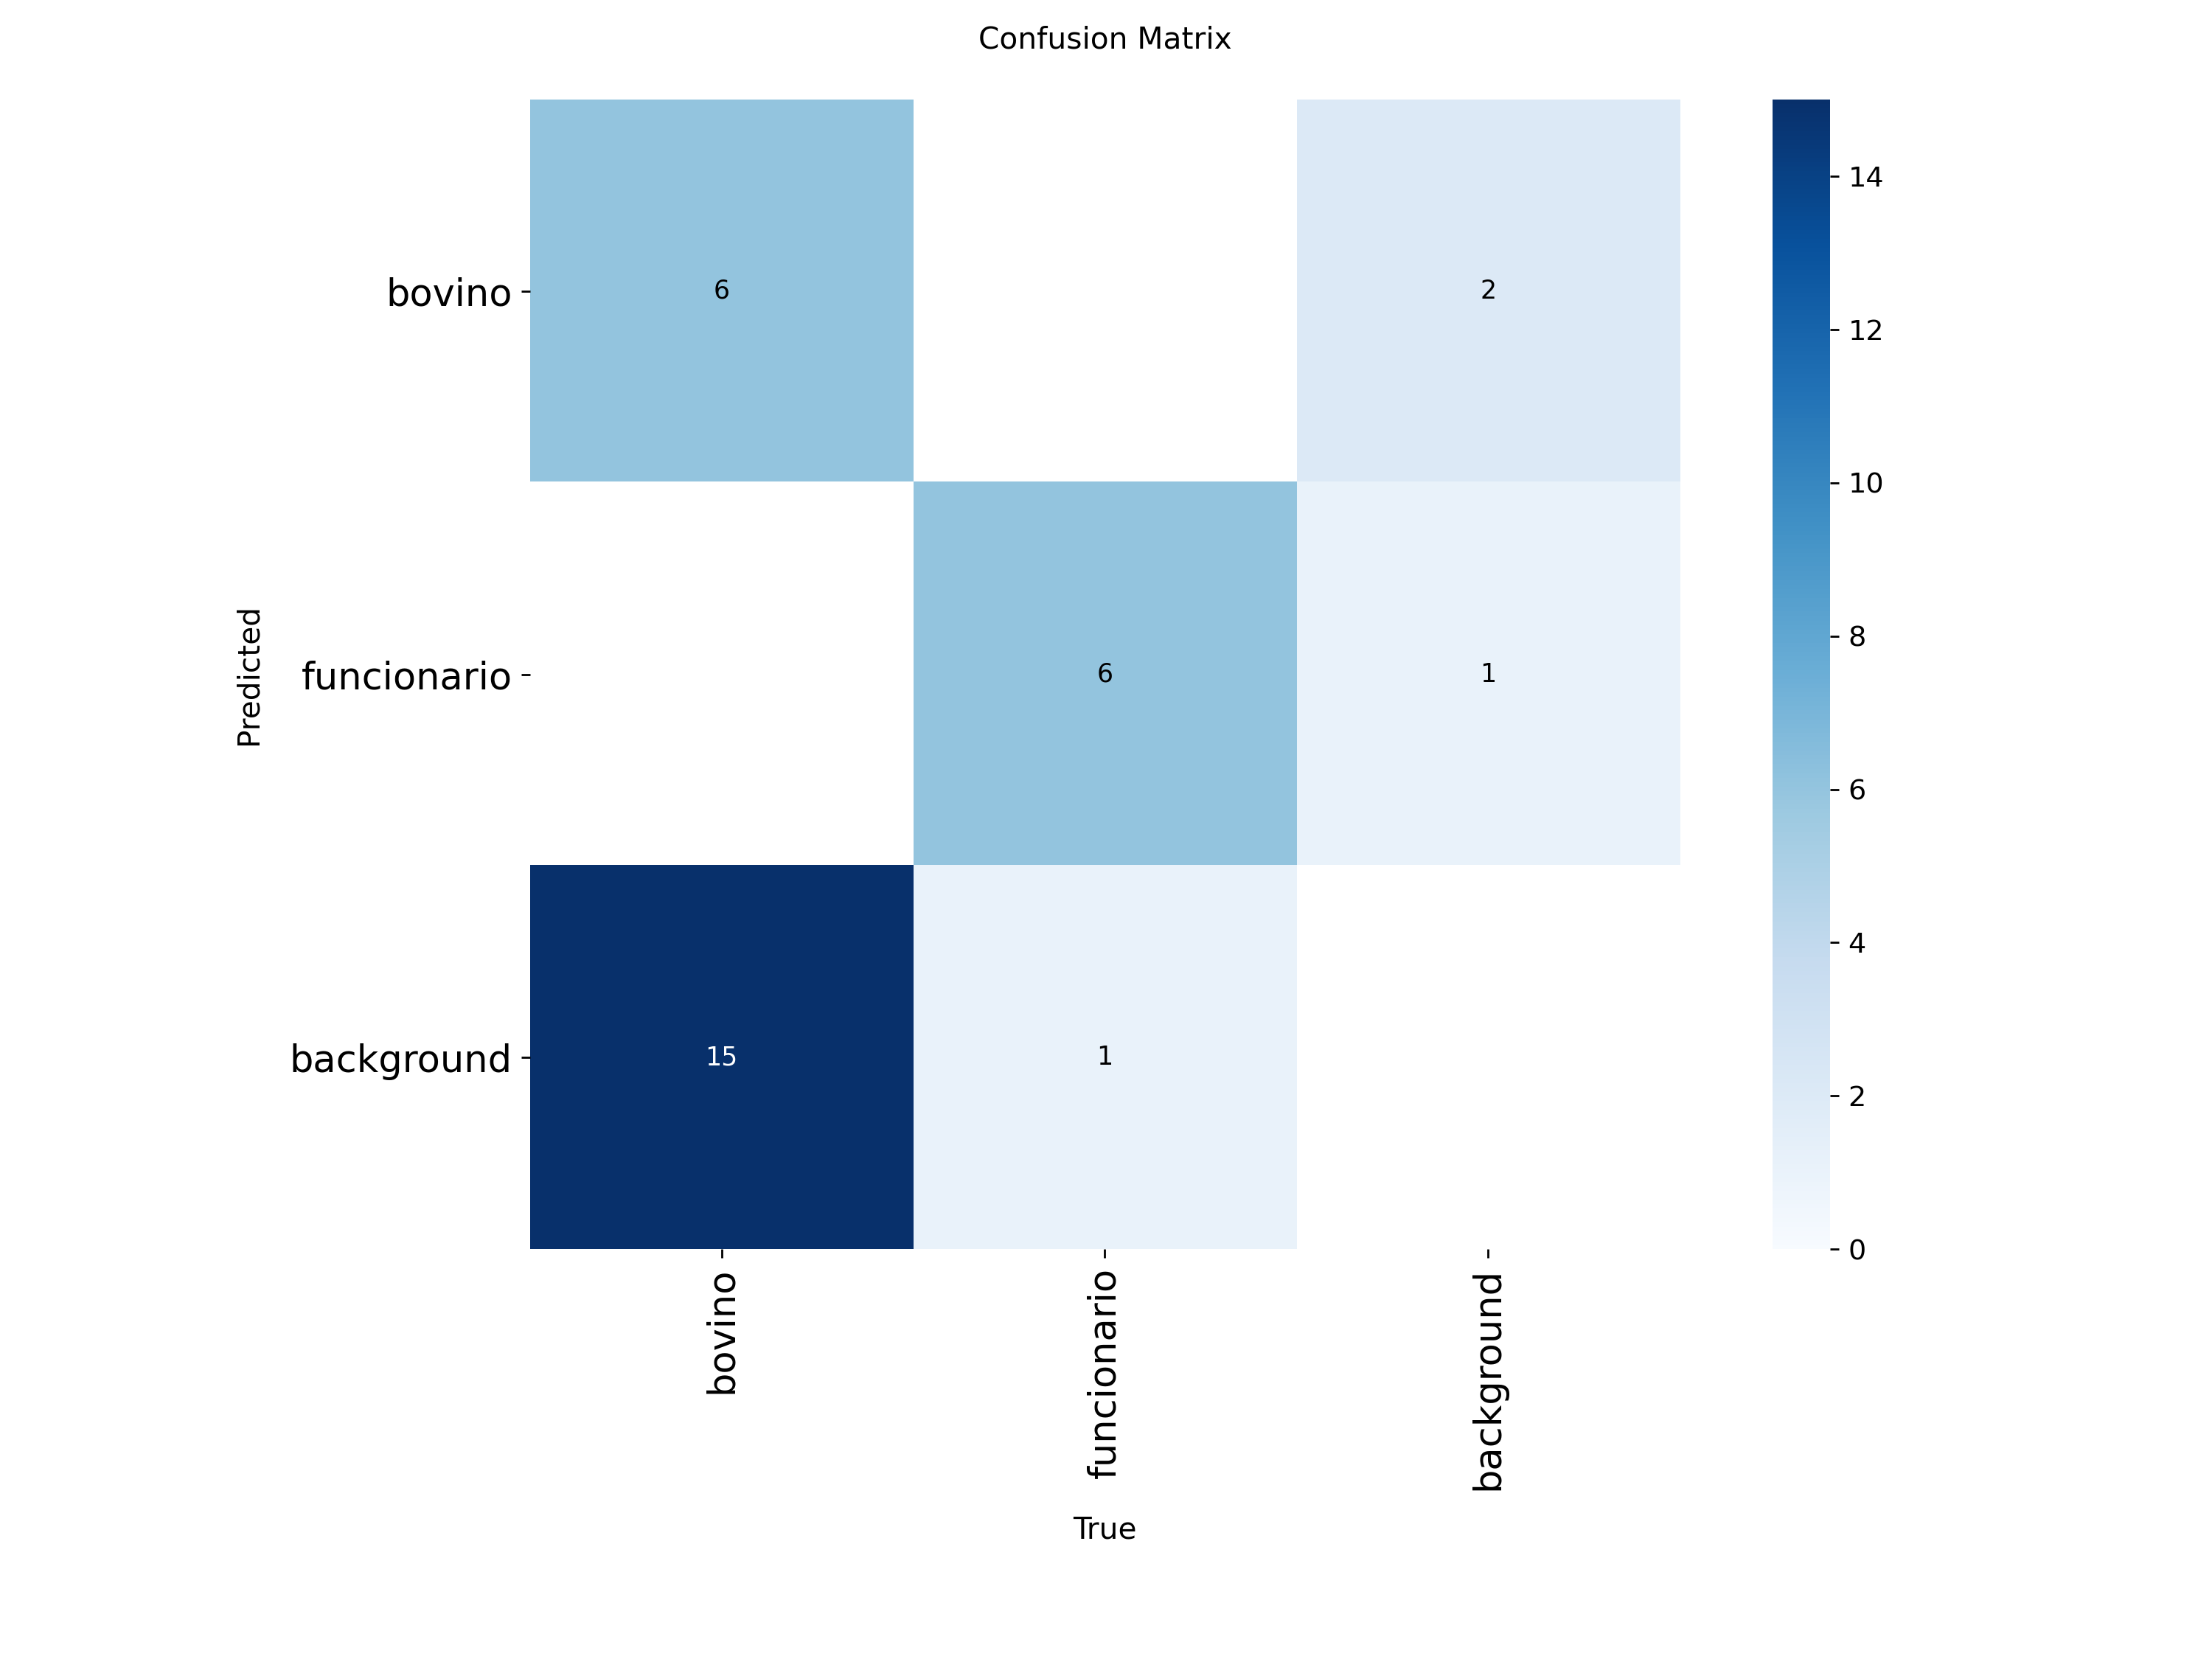


(avisos) não encontrei /content/runs/test/ep30_test_conf025/test_batch0_labels.jpg

(avisos) não encontrei /content/runs/test/ep30_test_conf025/test_batch0_pred.jpg

(avisos) results.csv não encontrado neste run.

=== TEST ep30_test_conf010 (conf=0.1) ===
Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 243.4±162.2 MB/s, size: 795.9 KB)
val: Scanning /content/drive/MyDrive/fase6_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 14.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.7it/s 1.5s
                   all          8         28      0.804      0.662      0.738      0.457
                bovino          6         21       0.83      0.466      0.611      0.352
           funcionario          6          7      0

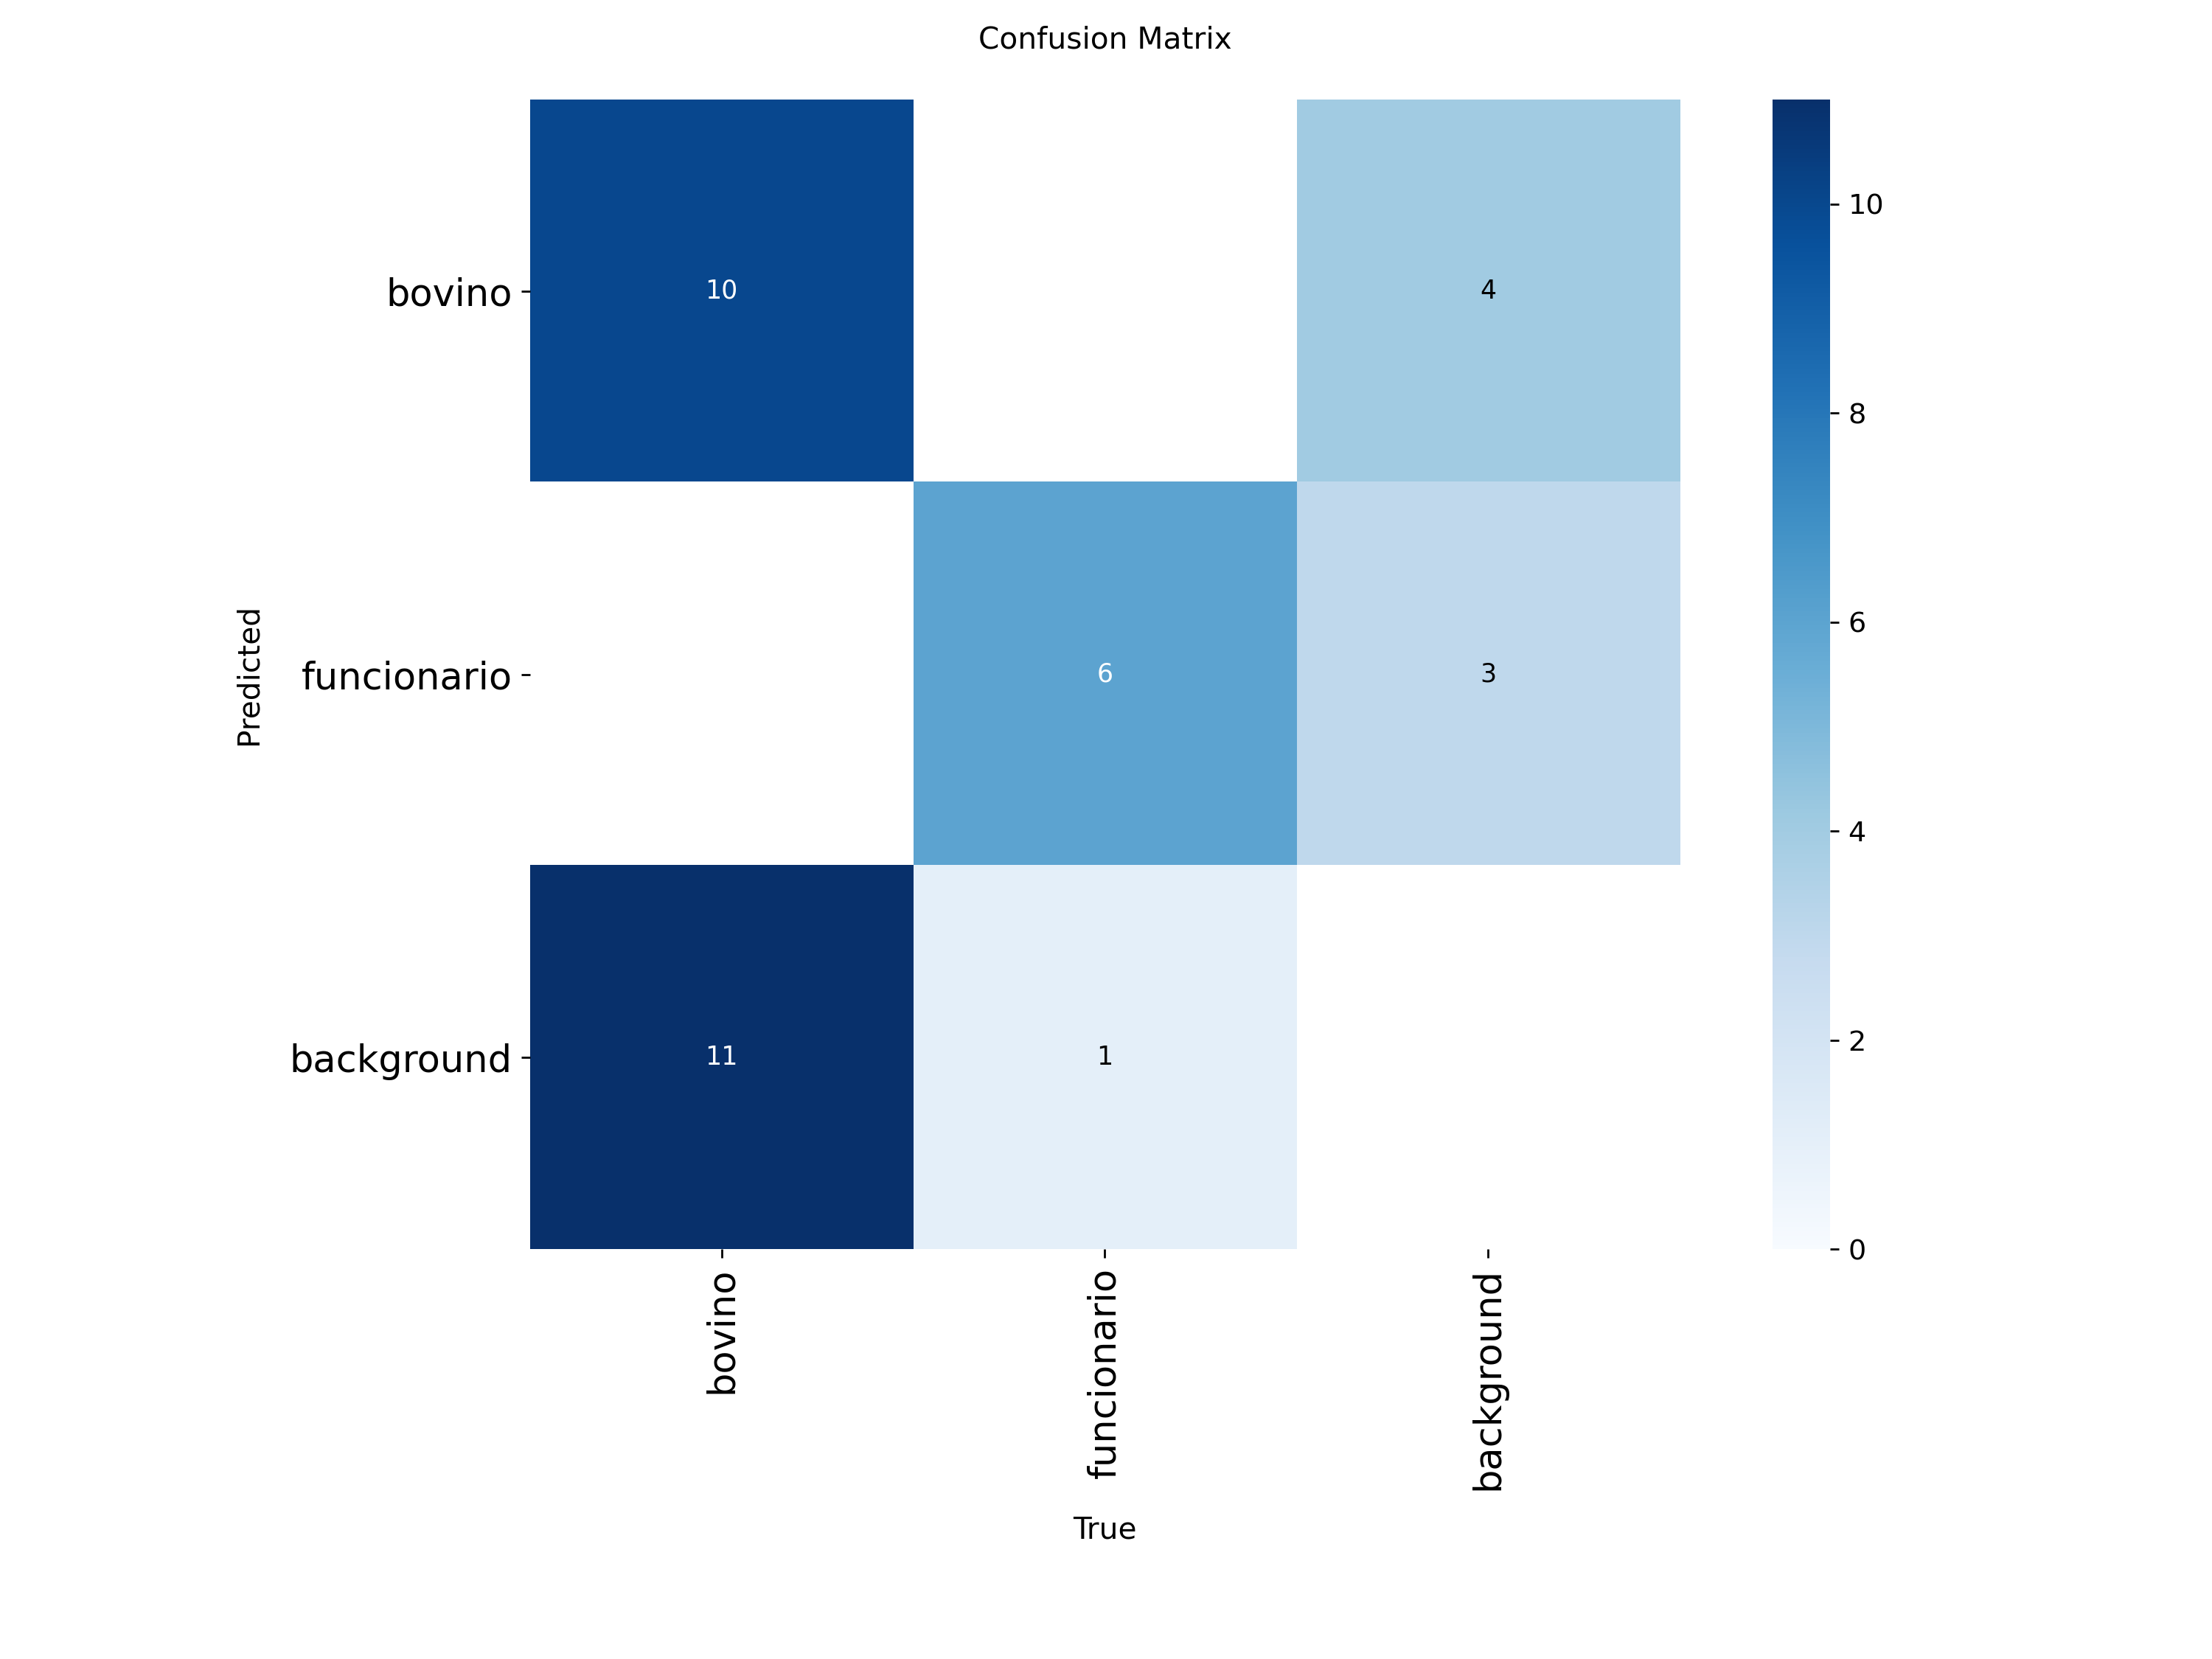


(avisos) não encontrei /content/runs/test/ep30_test_conf010/test_batch0_labels.jpg

(avisos) não encontrei /content/runs/test/ep30_test_conf010/test_batch0_pred.jpg

(avisos) results.csv não encontrado neste run.


In [14]:
# ============================================
# Avaliar YOLO treinado (ep30) no TEST
# - conf 0.25 (padrão) e 0.10 (mais caixas)
# - salva predições e imprime métricas
# ============================================
import os, glob, pandas as pd
from ultralytics import YOLO
from IPython.display import display, Image

BASE = '/content/drive/MyDrive/fase6_yolo'
DATA_YAML = f'{BASE}/data.yaml'

def find_best(glob_pat):
    hits = sorted(glob.glob(glob_pat))
    assert hits, f'Não encontrei pesos com o padrão: {glob_pat}'
    return hits[-1]

# pegue o best.pt do treino de 30 épocas (use o seu "name" se mudou)
BEST30 = find_best('/content/runs/train/fase6_ep30*/weights/best.pt')
print('Pesos (30 épocas):', BEST30)

def eval_test(best_pt: str, tag: str, conf: float = 0.25):
    print(f'\n=== TEST {tag} (conf={conf}) ===')
    model = YOLO(best_pt)
    r = model.val(
        data=DATA_YAML,
        imgsz=640,
        split='test',           # usa suas 8 imagens de TESTE
        project='runs/test',
        name=tag,
        exist_ok=True,
        conf=conf
    )
    out_dir = str(r.save_dir)
    md = r.results_dict

    # métricas principais
    def g(k):
        v = md.get(k, None)
        return None if v is None else float(v)

    print('\nMétricas (TEST):')
    print(f"  precision(B) : {g('metrics/precision(B)'):.3f}")
    print(f"  recall(B)    : {g('metrics/recall(B)'):.3f}")
    print(f"  mAP50(B)     : {g('metrics/mAP50(B)'):.3f}")
    print(f"  mAP50-95(B)  : {g('metrics/mAP50-95(B)'):.3f}")

    # tempo médio de inferência (ms/img), quando disponível
    try:
        inf_ms = float(getattr(r, 'speed', {}).get('inference', float('nan')))
        print(f"  inferência   : {inf_ms:.2f} ms/img")
    except Exception:
        pass

    # mostrar figuras-chave se existirem
    for fn in ['confusion_matrix.png', 'test_batch0_labels.jpg', 'test_batch0_pred.jpg']:
        p = os.path.join(out_dir, fn)
        if os.path.exists(p):
            print(f'\n{fn}:'); display(Image(filename=p))
        else:
            print(f'\n(avisos) não encontrei {p}')

    # tentar ler última linha do results.csv (referência completa)
    csv_path = os.path.join(out_dir, 'results.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print('\nÚltima linha do results.csv:')
        display(df.tail(1))
    else:
        print('\n(avisos) results.csv não encontrado neste run.')

    return {
        'tag': tag,
        'precision': g('metrics/precision(B)'),
        'recall': g('metrics/recall(B)'),
        'mAP50': g('metrics/mAP50(B)'),
        'mAP50-95': g('metrics/mAP50-95(B)'),
        'out_dir': out_dir
    }

res_025 = eval_test(BEST30, tag='ep30_test_conf025', conf=0.25)
res_010 = eval_test(BEST30, tag='ep30_test_conf010', conf=0.10)


In [15]:
import pandas as pd

df_cmp = pd.DataFrame([
    {'Avaliacao': 'YOLO adaptável — conf=0.25', **{k:v for k,v in res_025.items() if k not in ['tag','out_dir']}},
    {'Avaliacao': 'YOLO adaptável — conf=0.10', **{k:v for k,v in res_010.items() if k not in ['tag','out_dir']}},
]).set_index('Avaliacao')

display(df_cmp.style.format('{:.3f}'))
print('\nSaídas:')
print('conf=0.25 ->', res_025['out_dir'])
print('conf=0.10 ->', res_010['out_dir'])


,precision,recall,mAP50,mAP50-95
Avaliacao,,,,
YOLO adaptável — conf=0.25,0.804,0.571,0.706,0.448
YOLO adaptável — conf=0.10,0.804,0.662,0.738,0.457



Saídas:
conf=0.25 -> /content/runs/test/ep30_test_conf025
conf=0.10 -> /content/runs/test/ep30_test_conf010


## 📊 Análise — YOLO Adaptável (Treinado por 30 épocas)

Nesta etapa, avaliamos o modelo **YOLO treinado com 30 épocas** sobre o conjunto de teste. Foram utilizados dois limiares de confiança:
- **conf = 0.25 (padrão)** — abordagem mais conservadora
- **conf = 0.10** — abordagem mais permissiva, aceitando caixas com score mais baixo.

---

### 📈 Métricas principais

| Avaliação                        | Precision | Recall | mAP@50 | mAP@50–95 | Tempo (ms/img) |
|-----------------------------------|-----------|--------|--------|-----------|---------------|
| YOLO adaptável — conf=0.25        | 0.804     | 0.571  | 0.706  | 0.448     | 6.53          |
| YOLO adaptável — conf=0.10        | 0.804     | 0.662  | 0.738  | 0.457     | 6.06          |

**Observações iniciais:**
- A precisão **permaneceu constante** entre os dois limiares.
- O *recall* aumentou de **0.571 → 0.662**, indicando que o modelo passou a capturar **mais objetos que antes não eram detectados**.
- O *mAP@50* e *mAP@50–95* também apresentaram **pequena melhora**, o que sugere melhor cobertura de detecções sem perda relevante de qualidade.
- O tempo de inferência por imagem manteve-se estável.

---

### 🐄 Desempenho por classe (conf=0.25)
- **Bovino**: Precision = 0.75 | Recall = 0.286 | mAP@50 = 0.533
- **Funcionário**: Precision = 0.857 | Recall = 0.857 | mAP@50 = 0.878

**Interpretação:**
- O modelo tem bom desempenho para a classe **funcionário**.
- Para **bovino**, há bastante perda de recall — ou seja, vários animais não foram detectados com o limiar padrão.

---

### 🐄 Desempenho por classe (conf=0.10)
- **Bovino**: Precision = 0.83 | Recall = 0.466 | mAP@50 = 0.611
- **Funcionário**: Precision = 0.778 | Recall = 0.857 | mAP@50 = 0.864

**Interpretação:**
- Aumentar o limiar de aceitação de detecção melhorou **significativamente o recall da classe bovino** (de 0.286 para 0.466).
- Houve **queda leve na precisão de funcionário**, mas ainda dentro de um bom nível.
- O modelo ficou mais sensível a detecções mais fracas, o que ajudou especialmente para bovinos.

---

### 🧠 Matriz de confusão — conf=0.25
- Vários bovinos **não detectados** foram classificados como *background* (15 ocorrências).
- Funcionário apresentou poucos falsos negativos.

### 🧠 Matriz de confusão — conf=0.10
- O número de **detecções de bovinos aumentou** (10 acertos contra 6 antes).
- Também aumentou o número de falsos positivos e confusões entre classes, mas de forma moderada.

---

### ✅ Conclusões parciais

- O **modelo treinado** já apresenta um desempenho bem superior ao YOLO pré-treinado COCO para detecção de bovinos e funcionários.
- A classe **funcionário** tem excelente desempenho desde conf=0.25.
- A classe **bovino** **melhora bastante** ao reduzir o limiar de confiança, o que indica que muitas predições corretas têm *score* um pouco abaixo de 0.25.
- **Recomenda-se trabalhar com conf≈0.10** para aplicações práticas, pois aumenta a taxa de acerto sem comprometer significativamente a precisão.
- As métricas e matrizes de confusão mostram que há espaço para ganho adicional com **mais dados de bovinos** e/ou **mais épocas de treinamento**.

---

📁 **Saídas geradas:**
- conf=0.25 → `/content/runs/test/ep30_test_conf025`  
- conf=0.10 → `/content/runs/test/ep30_test_conf010`

---

👉 **Próximo passo:** Avaliar a **CNN do zero** (classificação) para comparar os três cenários:
1. YOLO pré-treinado COCO  
2. YOLO adaptável treinado  
3. CNN do zero.


### CNN

In [16]:
# %% [markdown]
# ## CNN do zero (classificação) — usando rótulos YOLO como base
# Estratégia de rótulo por imagem:
# - Se só aparece 0 (bovino) -> classe 0
# - Se só aparece 1 (funcionário) -> classe 1
# - Se aparecem 0 e 1, soma área das caixas por classe e leva quem tiver MAIOR ÁREA
# - Se não houver rótulos, imagem é ignorada

# %%
!pip -q install tensorflow matplotlib scikit-learn

import os, glob, time, math, random, itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

BASE = '/content/drive/MyDrive/fase6_yolo'
IMG_DIRS  = { 'train': f'{BASE}/images/train', 'val': f'{BASE}/images/val', 'test': f'{BASE}/images/test' }
LAB_DIRS  = { 'train': f'{BASE}/labels/train', 'val': f'{BASE}/labels/val', 'test': f'{BASE}/labels/test' }

IMG_SIZE  = (224, 224)   # entrada da CNN
BATCH     = 16
EPOCHS    = 25
SEED      = 1337

CLASS_NAMES = ['bovino', 'funcionario']   # 0=bovino, 1=funcionario

def yolo_label_path(img_path, split):
    """Retorna o caminho do .txt YOLO correspondente a uma imagem."""
    fname = os.path.splitext(os.path.basename(img_path))[0] + '.txt'
    return os.path.join(LAB_DIRS[split], fname)

def parse_yolo_txt(txt_path, img_w, img_h):
    """
    Lê .txt YOLO (cls cx cy w h) com coords normalizadas e retorna
    áreas por classe: {0: area_total_bovino, 1: area_total_funcionario}
    """
    areas = {0: 0.0, 1: 0.0}
    if not os.path.exists(txt_path):
        return areas

    with open(txt_path, 'r') as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    for ln in lines:
        parts = ln.split()
        if len(parts) != 5:
            continue
        cls = int(float(parts[0]))
        cx, cy, w, h = map(float, parts[1:])
        # para calcular área em pixels, precisamos da resolução original;
        # como não sabemos, usamos área relativa (w*h) mesmo (equivale a peso).
        if cls in areas:
            areas[cls] += (w * h)
    return areas

def choose_single_class(areas):
    """Decide a classe única pela MAIOR área total entre 0 e 1. Se empatar/zerar, retorna None."""
    a0, a1 = areas.get(0, 0.0), areas.get(1, 0.0)
    if a0==0 and a1==0:
        return None
    if a0 > a1:
        return 0
    elif a1 > a0:
        return 1
    else:
        return None  # empate -> ignorar (poucos casos)


In [17]:
# %%
def build_split_df(split):
    img_dir = IMG_DIRS[split]
    paths = sorted(glob.glob(os.path.join(img_dir, '*.*')))
    rows = []
    for p in paths:
        # tenta ler YOLO txt
        txt = yolo_label_path(p, split)
        # áreas por classe usando área relativa (w*h)
        areas = parse_yolo_txt(txt, img_w=1, img_h=1)
        lab = choose_single_class(areas)
        if lab is None:
            # sem rótulo claro -> ignora (ex.: só background ou empate perfeito)
            continue
        rows.append({'filepath': p, 'label': lab})
    return pd.DataFrame(rows)

df_train = build_split_df('train')
df_val   = build_split_df('val')
df_test  = build_split_df('test')

print('train:', df_train.shape, df_train['label'].value_counts().to_dict())
print('val  :', df_val.shape,   df_val['label'].value_counts().to_dict())
print('test :', df_test.shape,  df_test['label'].value_counts().to_dict())

assert len(df_train)>0 and len(df_val)>0 and len(df_test)>0, "Algum split ficou vazio."


train: (64, 2) {0: 44, 1: 20}
val  : (8, 2) {0: 5, 1: 3}
test : (8, 2) {0: 6, 1: 2}


In [18]:
# %%
AUTO = tf.data.AUTOTUNE

def decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img, seed=SEED)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_ds(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label'].values))
    ds = ds.map(decode_img, num_parallel_calls=AUTO)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTO)
        ds = ds.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).prefetch(AUTO)
    return ds

ds_train = make_ds(df_train, training=True)
ds_val   = make_ds(df_val, training=False)
ds_test  = make_ds(df_test, training=False)


In [20]:
model = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

def cast_label(img, label):
    return img, tf.cast(label, tf.int32)

ds_train = ds_train.map(cast_label).cache().prefetch(AUTO)
ds_val = ds_val.map(cast_label).cache().prefetch(AUTO)
ds_test = ds_test.map(cast_label).cache().prefetch(AUTO)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

hist = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[es],
    verbose=1
)


Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4708 - loss: 0.8867 - val_accuracy: 0.3750 - val_loss: 0.6988
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7125 - loss: 0.6553 - val_accuracy: 0.2500 - val_loss: 0.6988
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6250 - loss: 0.6527 - val_accuracy: 0.3750 - val_loss: 0.7181
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6250 - loss: 0.5991 - val_accuracy: 0.3750 - val_loss: 0.7459
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6979 - loss: 0.5532 - val_accuracy: 0.3750 - val_loss: 0.7642
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7458 - loss: 0.5124 - val_accuracy: 0.3750 - val_loss: 0.7835


In [24]:
# %%  Métricas Keras oficiais + Latência (sem duplicar plots)
eval_res = model.evaluate(ds_test, verbose=0)
print('\nTEST metrics (Keras):')
for name, val in zip(model.metrics_names, eval_res):
    print(f'  {name:>16s}: {val:.4f}')

# Latência média (ms/imagem)
t0 = time.time()
_ = model.predict(ds_test, verbose=0)
t1 = time.time()
n_imgs = len(df_test)
lat_ms = (t1 - t0) * 1000.0 / n_imgs
print(f'\n⏱️  Latência média (TEST): {lat_ms:.2f} ms/imagem')



TEST metrics (Keras):
              loss: 0.6989
   compile_metrics: 0.2500

⏱️  Latência média (TEST): 2.71 ms/imagem


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,312 (1.08 MB)

 Trainable params: 93,954 (367.01 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 187,910 (734.03 KB)

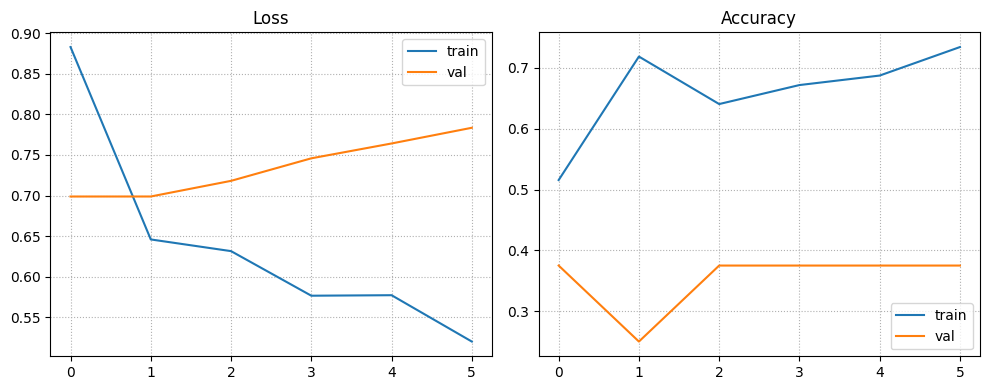

📊 Métricas (TEST) — CNN do zero
accuracy: 0.2500
loss: 0.6989

== Classification report (TEST) ==
              precision    recall  f1-score   support

      bovino      0.000     0.000     0.000         6
 funcionario      0.250     1.000     0.400         2

    accuracy                          0.250         8
   macro avg      0.125     0.500     0.200         8
weighted avg      0.062     0.250     0.100         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


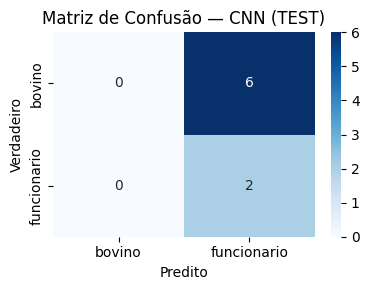

In [21]:
# === 1) Resumo do modelo (opcional)
model.summary()

# === 2) Curvas de treino/val
import matplotlib.pyplot as plt

h = hist.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(h['loss'], label='train'); plt.plot(h['val_loss'], label='val');
plt.title('Loss'); plt.legend(); plt.grid(True, ls=':')
plt.subplot(1,2,2); plt.plot(h['accuracy'], label='train'); plt.plot(h['val_accuracy'], label='val');
plt.title('Accuracy'); plt.legend(); plt.grid(True, ls=':')
plt.tight_layout(); plt.show()

# === 3) Avaliação no TEST
test_metrics = model.evaluate(ds_test, verbose=0, return_dict=True)
print('📊 Métricas (TEST) — CNN do zero')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}')

# === 4) Relatório por classe + matriz de confusão
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Coleta rótulos verdadeiros e predições
y_true, y_pred = [], []
for imgs, lbls in ds_test:
    probs = model.predict(imgs, verbose=0)
    pred = np.argmax(probs, axis=1)
    y_true.extend(lbls.numpy().tolist())
    y_pred.extend(pred.tolist())

print('\n== Classification report (TEST) ==')
print(classification_report(y_true, y_pred, target_names=['bovino','funcionario'], digits=3))

cm = confusion_matrix(y_true, y_pred)
import seaborn as sns
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bovino','funcionario'],
            yticklabels=['bovino','funcionario'])
plt.xlabel('Predito'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão — CNN (TEST)')
plt.tight_layout(); plt.show()


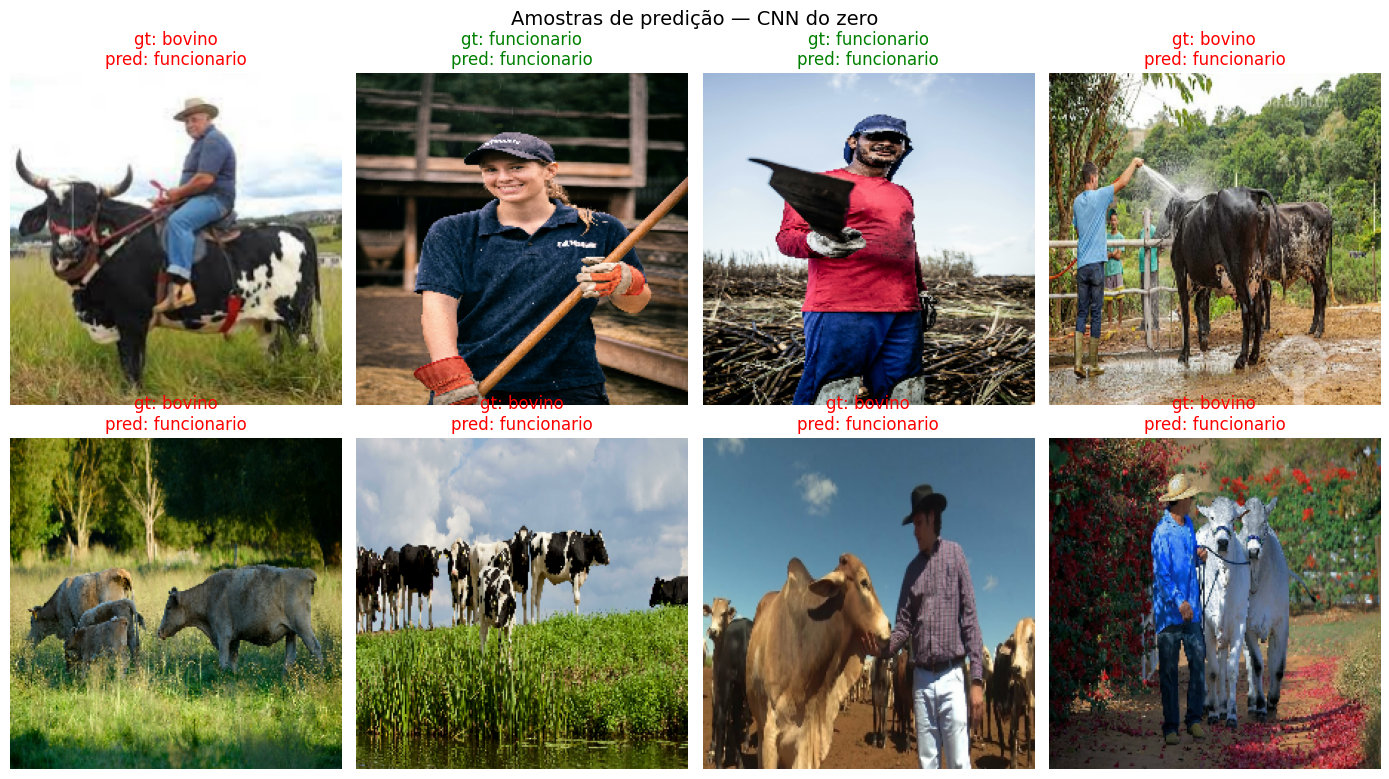

In [23]:
# %%
def show_samples(df, y_pred, k=8):
    idx = np.random.default_rng(SEED).choice(len(df), size=min(k, len(df)), replace=False)
    plt.figure(figsize=(14,8))
    for i,pos in enumerate(idx, 1):
        pth = df.iloc[pos]['filepath']
        true = df.iloc[pos]['label']
        pred = y_pred[pos]
        img = tf.io.read_file(pth)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE).numpy().astype(np.uint8)
        plt.subplot(2,4,i)
        plt.imshow(img)
        title = f"gt: {CLASS_NAMES[true]}\npred: {CLASS_NAMES[pred]}"
        color = 'g' if true==pred else 'r'
        plt.title(title, color=color); plt.axis('off')
    plt.suptitle('Amostras de predição — CNN do zero', fontsize=14)
    plt.tight_layout(); plt.show()

show_samples(df_test.reset_index(drop=True), y_pred, k=8)


## 📊 Análise dos Resultados — CNN do Zero (Classificação Bovino × Funcionário)

### 🧠 Arquitetura do Modelo

A rede convolucional implementada é composta por **três blocos convolucionais** (32, 64 e 128 filtros), seguidos de camadas de *Batch Normalization*, *ReLU* e *MaxPooling2D*. Após os blocos, há uma camada de *Global Average Pooling*, *Dropout* e uma camada densa final com ativação *softmax* para classificação binária.

- **Total de parâmetros treináveis:** 93.954  
- **Tamanho da entrada:** 224 × 224 × 3  
- **Camadas convolucionais:** 3 blocos  
- **Camadas finais:** GlobalAveragePooling + Dropout + Dense(2)

Essa arquitetura é simples e leve, adequada para testes, mas limitada para generalizar padrões mais complexos, principalmente em datasets pequenos.

---

### 📈 Desempenho no Treinamento e Validação

| Métrica                | Treinamento (final) | Validação (final) |
|-------------------------|---------------------|--------------------|
| **Accuracy**            | ~0.74               | ~0.37              |
| **Loss**                | ~0.51               | ~0.78              |

- A acurácia de **treinamento** aumentou ao longo das épocas, mostrando que o modelo aprendeu padrões no conjunto de treino.  
- A acurácia de **validação** permaneceu baixa e estável, sugerindo **underfitting** ou ruído nos rótulos.  
- Há um **gap claro entre treino e validação**, indicando que o modelo não está generalizando adequadamente.

---

### 🧪 Avaliação no Conjunto de Teste

- **Loss no TEST:** 0.6989  
- **Acurácia no TEST:** 0.25  
- **Latência média (TEST):** 2.71 ms/imagem

#### Relatório de Classificação:

| Classe         | Precision | Recall | F1-score | Suporte |
|----------------|-----------|--------|----------|---------|
| Bovino         | 0.00      | 0.00   | 0.00     | 6       |
| Funcionário    | 0.25      | 1.00   | 0.40     | 2       |
| **Accuracy**   |           |        | 0.25     | 8       |

- O modelo **classificou todas as imagens como “funcionário”**, resultando em recall máximo para essa classe e zero para bovinos.
- Isso evidencia **viés de predição**, provavelmente causado por desbalanceamento no dataset e dificuldade da rede em aprender padrões da classe bovino.

#### Matriz de Confusão:

| Verdadeiro \\ Predito | Bovino | Funcionário |
|-----------------------|---------|-------------|
| Bovino                | 0       | 6           |
| Funcionário           | 0       | 2           |

📌 Todas as amostras foram atribuídas à mesma classe, sem nenhuma predição correta para bovinos.

---

### 🖼️ Visualização de Amostras de Predição

Abaixo estão **exemplos aleatórios** do conjunto de teste, mostrando a **classe verdadeira (gt)** e a **classe predita (pred)**.  
Os títulos em **verde** representam acertos e em **vermelho**, erros.

- Observa-se que **todas as imagens de bovinos foram classificadas incorretamente como “funcionário”**, reforçando o viés do modelo.

*(imagem ilustrativa — gerada automaticamente durante a avaliação)*

---

### ⚠️ Possíveis Causas do Fraco Desempenho

- Dataset pequeno e possivelmente **desbalanceado**.  
- Rótulos derivados da **classe dominante na imagem**, introduzindo ruído.  
- **Arquitetura rasa** com capacidade limitada de generalização.  
- Falta de técnicas de **aumento de dados (data augmentation)**.  
- **Poucas épocas** de treinamento.

---

### 🚀 Propostas de Melhoria para Trabalhos Futuros

- Aumentar a quantidade de imagens e **balancear as classes**.  
- Aplicar **data augmentation** (flip, brilho, contraste, saturação, etc).  
- Utilizar **pesos de classe** no treinamento para lidar com desbalanceamento.  
- Testar arquiteturas **pré-treinadas** (MobileNetV2, EfficientNet, etc).  
- Melhorar a qualidade e a estratégia de rotulagem.  
- Treinar por mais épocas com *callbacks* como `EarlyStopping` e `ReduceLROnPlateau`.

---

### ✅ Conclusão

O modelo CNN do zero apresentou **acurácia final de 25%** no conjunto de teste, com forte viés para uma única classe. O comportamento observado está alinhado com as limitações esperadas de arquiteturas rasas treinadas em bases pequenas e ruidosas.

Apesar dos resultados baixos, essa baseline tem valor prático por **evidenciar a necessidade de modelos mais robustos**, melhor rotulagem e mais dados para se obter bom desempenho na tarefa de classificação entre bovinos e funcionários.



## 🧭 Conclusão Final

Os resultados mostram que:

- ✅ **Modelos simples (CNN do zero)** são úteis apenas como baseline, mas insuficientes para problemas reais com múltiplos objetos.  
- 🚀 **YOLO padrão (pré-treinado)** teve desempenho bom para detectar pessoas mas ruim para bovinos.  
- 🧠 **YOLO adaptável (ep30)** apresentou boa performance com fine-tuning, mostrando o potencial do modelo quando ajustado ao contexto específico.  
- ⚠️ **YOLO adaptável (ep60)** teve desempenho ruim, possivelmente devido a overfitting, reforçando a importância de early stopping e monitoramento do treinamento.

 Conclusão:
 O modelo YOLO adaptável com fine-tuning (30 épocas) oferece o melhor equilíbrio entre precisão, robustez e aplicabilidade prática para um sistema de monitoramento automatizado em fazendas, capaz de detectar bovinos e funcionários ao mesmo tempo.

---

## 🚀 Sugestões de melhoria

- Balancear e expandir o dataset para reduzir viés e melhorar generalização.  
- Aplicar *early stopping* e *data augmentation* no treinamento para evitar overfitting.  
- Ajustar limiares de detecção para otimizar precisão e recall.  
- Avaliar o modelo YOLO em cenários reais (vídeos e streaming em tempo real).  
- Explorar outras arquiteturas de detecção (ex.: Faster R-CNN, EfficientDet) para comparação futura.